# 03 — Baseline Structural Analysis (Go/No-Go gate, v2)

Loads attribution statistics and evaluates whether the base-model structural
fingerprint shows sufficient variation to justify the LoRA fine-tuning experiment.
Mirrors supervisor's `analyze.py` evaluation.

**Default (v2 two-pod merge):** combines `stats_base_v2.json` (pod 1) with
`stats_base_v2_from160.json` (pod 2 / `02b_baseline_attribution_pod2_from160.ipynb`),
deduplicating by `prompt_id` (prefers `attribution_succeeded` on collision).

**Pilot:** set `USE_PILOT=True` to load only `stats_base.json` (v1 pilot).

**Analysis sections:**
1. Summary table by `(family, label)` — sanity-check dataset balance.
2. Metric distributions by family, label and tail (IQR check).
3. Calibration: logit gap by label.
4. Prune-curve and top-K=20 diagnostics.
4b. **Paired v2 vs v3** TF-order flip (first-token + LOO on 90 shared items).
5. **Main classifier:** binary T/F subset (`family ∈ {numeric_validity, geometry_claim}`);  
   §5 baseline vs **§5b** (same protocol, **`layer_hist_*` vs aggregates**);
   stratified holdout **§5c**/**§5d** (prompt OHE only on **§5d**).
6. **Tail diagnostic:** predict `tail` from structural features (format-detector check).
7. Per-tail facet plots for verdict scatter.
8. **Go/No-Go:** emphasis on IQR spread and protocol readiness (negative T/F classifier result is a valid outcome per supervisor findings).

**No GPU required.** Run locally or on RunPod CPU.

## 0 — Environment Setup

In [1]:
import os
import sys
from pathlib import Path

def _find_repo_root():
    start = Path.cwd().resolve()
    for directory in [start, *start.parents]:
        if (directory / "circuit_tracer" / "__init__.py").is_file():
            return directory
    workspace = Path("/workspace")
    if workspace.is_dir():
        for child in workspace.iterdir():
            if child.is_dir() and (child / "circuit_tracer" / "__init__.py").is_file():
                return child
    repo_override = os.environ.get("CT_REPO_DIR")
    if repo_override:
        override_path = Path(repo_override).expanduser().resolve()
        if (override_path / "circuit_tracer" / "__init__.py").is_file():
            return override_path
    return None

_root = _find_repo_root()
if _root is not None:
    if str(_root) not in sys.path:
        sys.path.insert(0, str(_root))
    _my_work = _root / "my_work"
    if str(_my_work) not in sys.path:
        sys.path.insert(0, str(_my_work))
    print(f"Repo root: {_root}")
else:
    print("WARNING: could not locate circuit_tracer repo.")

MY_WORK = _my_work if _root else Path(".").resolve()

STATISTICS_DIR = MY_WORK / "results" / "statistics"

# Toggle: set USE_PILOT=True to load the v1 pilot stats_base.json only.
USE_PILOT = False

# When USE_PILOT=False: merge pod1 + pod2 shard files (same v2 schema).
USE_MERGE_V2_SHARDS = True
STATS_FILE_POD1 = STATISTICS_DIR / "stats_base_v2.json"
STATS_FILE_POD2 = STATISTICS_DIR / "stats_base_v2_from160.json"  # 02b notebook

if USE_PILOT:
    STATS_FILE = STATISTICS_DIR / "stats_base.json"
    print(f"Stats file (pilot): {STATS_FILE}")
else:
    print(f"Stats pod1       : {STATS_FILE_POD1}")
    print(f"Stats pod2       : {STATS_FILE_POD2}")
    print(f"Merging shards   : {USE_MERGE_V2_SHARDS}")
print(f"Using pilot data: {USE_PILOT}")

Repo root: /Users/Lacus/Documents/ELTE/Thesis/circuit-tracer-main
Stats pod1       : /Users/Lacus/Documents/ELTE/Thesis/circuit-tracer-main/my_work/results/statistics/stats_base_v2.json
Stats pod2       : /Users/Lacus/Documents/ELTE/Thesis/circuit-tracer-main/my_work/results/statistics/stats_base_v2_from160.json
Merging shards   : True
Using pilot data: False


## 1 — Load statistics

In [2]:
# Plain-English captions for structural / verdict scalars (03 cell 4 + prune_curve).
_PRUNE_T = ("0.50", "0.60", "0.70", "0.80", "0.90", "0.95", "0.99")

METRIC_DESCRIPTIONS = {
    "n_active_features": "Number of attribution features kept as active.",
    "edge_density": "After legacy pruning (nodes≥0.8, edges≥0.98): fraction of possible edges among kept nodes.",
    "mean_top50_score": "Mean absolute attribution score among the top-50 features.",
    "top10_over_top50": "Share of total top-50 |score| mass that sits in the top-10 features (concentration).",
    "layer_entropy": "Entropy (natural log base) of the layer histogram over those top-50 features.",
    "mean_error_node_weight": "Mean |cumulative score| on error/residual-type nodes (reconstruction slack).",
    "logit_gap": "Binary: log(prob(True)) − log(prob(False)); numeric: log(prob(target answer token)).",

    "layer_stats_mean": "Average layer index of active features weighted by counts (full-graph histogram).",
    "layer_stats_std": "Std dev of layer index over that histogram (spread across layers).",
    "layer_stats_median": "Median layer of active features (from cumulative layer mass).",
    "layer_stats_entropy_bits": "Shannon entropy in bits of the layer distribution across all active features.",

    "topk20_score_total": "Sum of |scores| over the supervisor top-20 features.",
    "topk20_score_gini": "Gini coefficient of |scores| among the top-20 (higher = more unequal masses).",
}

for _suffix in _PRUNE_T:
    METRIC_DESCRIPTIONS[f"n_kept_at_{_suffix}"] = (
        f"After pruning at node_threshold={_suffix} (edges fixed at 0.99): number of graph nodes kept."
    )
    METRIC_DESCRIPTIONS[f"n_edges_at_{_suffix}"] = (
        f"Same prune: edges kept among nodes above that node_threshold."
    )
    METRIC_DESCRIPTIONS[f"density_at_{_suffix}"] = (
        f"Same prune: directed edge density among kept nodes, edges / (n_kept × (n_kept−1))."
    )
    METRIC_DESCRIPTIONS[f"n_nodes_total_at_{_suffix}"] = (
        "Total slots in the node mask before counting kept nodes (same protocol as prune curve)."
    )
    METRIC_DESCRIPTIONS[f"n_edges_total_at_{_suffix}"] = (
        "Total slots in the edge mask for that prune step (denominator context for kept edges)."
    )

In [3]:
import importlib
import json
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110

import utils.graph_statistics as gs_mod
importlib.reload(gs_mod)
from utils.graph_statistics import load_statistics, aggregate_statistics, _flatten_nested, _binary_label_true


def _merge_stats_shards(*lists):
    """Merge stat lists by prompt_id. Prefer succeeded rows; tie-break: later list wins."""
    merged: dict = {}
    for lst in lists:
        for row in lst:
            pid = row.get("prompt_id")
            if pid is None:
                continue
            if pid not in merged:
                merged[pid] = row
            else:
                old, new = merged[pid], row
                old_ok = bool(old.get("attribution_succeeded"))
                new_ok = bool(new.get("attribution_succeeded"))
                if new_ok and not old_ok:
                    merged[pid] = new
                elif old_ok and not new_ok:
                    pass
                else:
                    merged[pid] = new
    return sorted(merged.values(), key=lambda r: str(r.get("prompt_id", "")))


if USE_PILOT:
    all_stats = load_statistics(STATS_FILE)
    print(f"Loaded single file: {len(all_stats)} rows")
elif USE_MERGE_V2_SHARDS:
    _a = load_statistics(STATS_FILE_POD1)
    _b = load_statistics(STATS_FILE_POD2)
    print(f"Pod1 file rows   : {len(_a)}  ({STATS_FILE_POD1.name})")
    print(f"Pod2 file rows   : {len(_b)}  ({STATS_FILE_POD2.name})")
    all_stats = _merge_stats_shards(_a, _b)
    print(f"Merged unique IDs: {len(all_stats)}")
else:
    all_stats = load_statistics(STATS_FILE_POD1)
    print(f"Loaded pod1 only : {len(all_stats)} rows")

stats = [s for s in all_stats if s.get("attribution_succeeded")]
stats_flat = [_flatten_nested(s) for s in stats]

print(f"Total entries  : {len(all_stats)}")
print(f"Succeeded      : {len(stats)}")
print(f"Success rate   : {len(stats)/len(all_stats):.1%}" if all_stats else "")
print()

# ── Summary table by (family, label) — mirrors supervisor analyze.py ──────────
def _label_str(s):
    lbl = s.get("label")
    try:
        return "true" if _binary_label_true(lbl) else "false"
    except Exception:
        return str(lbl)

summary: Counter = Counter()
for s in stats:
    key = (s.get("family", "?"), s.get("tail", "?"), _label_str(s))
    summary[key] += 1

print(f"{'family':<24} {'tail':<20} {'label':<8} {'n':>4}")
print("-" * 62)
for (fam, tail, lbl), cnt in sorted(summary.items()):
    print(f"{fam:<24} {tail:<20} {lbl:<8} {cnt:>4}")
print()

agg = aggregate_statistics(all_stats)

# Core scalar metrics for IQR check and classifier feature set.
# Prune-curve scalars are added dynamically below.
all_scalar_metrics = [
    'n_active_features', 'edge_density', 'mean_top50_score',
    'top10_over_top50', 'layer_entropy', 'mean_error_node_weight', 'logit_gap',
    'layer_stats_mean', 'layer_stats_std', 'layer_stats_median', 'layer_stats_entropy_bits',
    'topk20_score_total', 'topk20_score_gini',
]
# Detect prune-curve scalars from first succeeded row
if stats_flat:
    for _k in sorted(stats_flat[0]):
        if any(_k.startswith(p) for p in (
            "n_kept_at_", "n_edges_at_", "density_at_",
            "n_nodes_total_at_", "n_edges_total_at_",
        )):
            if _k not in all_scalar_metrics:
                all_scalar_metrics.append(_k)

print(f"{'Metric':<36} {'Mean':>10} {'Std':>10} {'Median':>10} {'IQR':>10}")
print("-" * 80)
for m in all_scalar_metrics:
    v = agg.get(m)
    if v:
        print(f"{m:<36} {v['mean']:>10.4f} {v['std']:>10.4f} {v['median']:>10.4f} {v['iqr']:>10.4f}")
    else:
        print(f"{m:<36} {'N/A':>10}")

Pod1 file rows   : 159  (stats_base_v2.json)
Pod2 file rows   : 141  (stats_base_v2_from160.json)
Merged unique IDs: 300
Total entries  : 300
Succeeded      : 300
Success rate   : 100.0%

family                   tail                 label       n
--------------------------------------------------------------
geometry_claim           answer_colon         false       6
geometry_claim           answer_colon         true        6
geometry_claim           the_answer_is        false       6
geometry_claim           the_answer_is        true        6
geometry_claim           true_or_false        false       6
geometry_claim           true_or_false        true        6
numeric_open             answer_colon         true       30
numeric_validity         answer_colon         false      39
numeric_validity         answer_colon         true       39
numeric_validity         the_answer_is        false      39
numeric_validity         the_answer_is        true       39
numeric_validity         true

## 2 — Distribution plots for each metric

Visualization of layer statistics over all questions and braoken down by correctness. This is just to check if the features look okay.

Saved: /Users/Lacus/Documents/ELTE/Thesis/circuit-tracer-main/my_work/results/statistics/base_metric_distributions.png


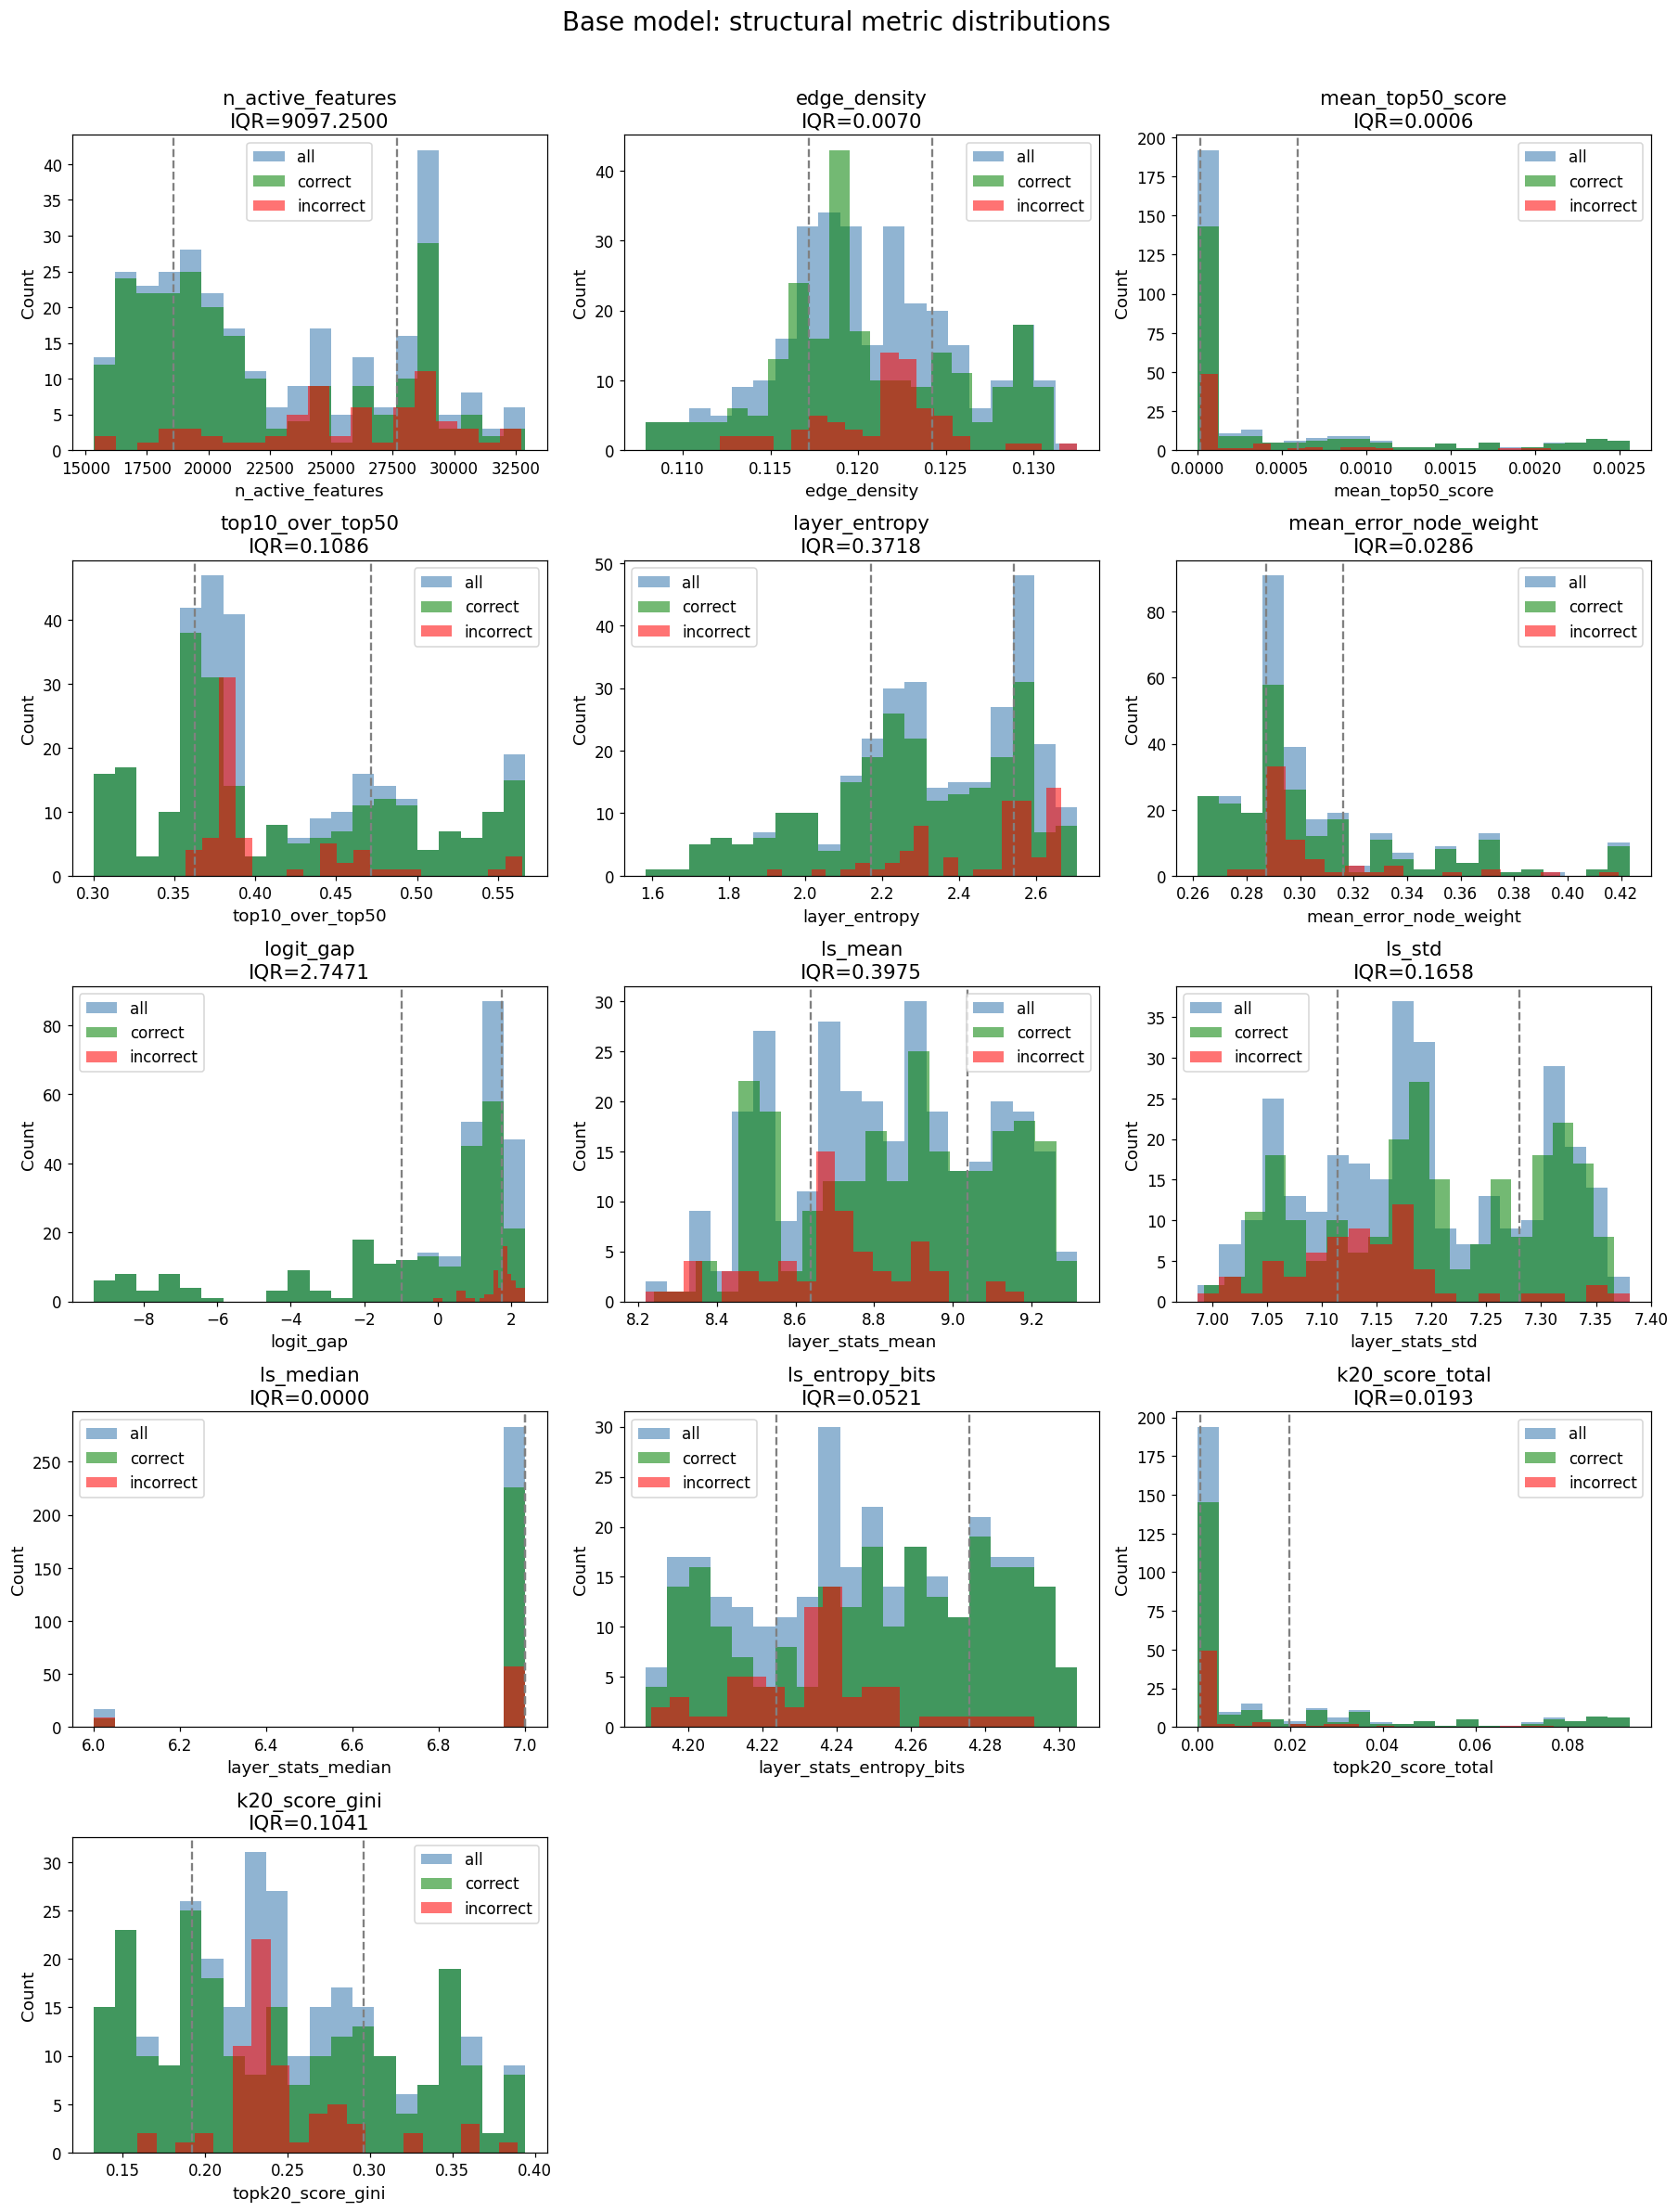

In [4]:
def _is_correct(s):
    """True if the model's argmax first-token matches ground-truth label."""
    if s.get("task_type", "binary") == "binary":
        pt = s.get("prob_true") or 0
        pf = s.get("prob_false") or 0
        try:
            return (pt > pf) == _binary_label_true(s["label"])
        except Exception:
            return False
    else:
        return (s.get("prob_target") or 0) > 0.0

# Core metrics (skip prune curve columns in this overview plot to keep it legible)
plot_metrics = [
    'n_active_features', 'edge_density', 'mean_top50_score',
    'top10_over_top50', 'layer_entropy', 'mean_error_node_weight', 'logit_gap',
    'layer_stats_mean', 'layer_stats_std', 'layer_stats_median', 'layer_stats_entropy_bits',
    'topk20_score_total', 'topk20_score_gini',
]

ncols = 3  # plot in 3 columns
nrows = -(-len(plot_metrics) // ncols)
base_fs = 14   # increased base font size
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5.5, nrows * 4.2))  # slightly bigger by col
axes = axes.flatten()

for ax, metric in zip(axes, plot_metrics):
    pairs = [(sf, s) for sf, s in zip(stats_flat, stats) if sf.get(metric) is not None]
    if not pairs:
        ax.set_title(f"{metric}\n(no data)", fontsize=base_fs)
        ax.axis('off')
        continue
    all_vals   = [sf[metric] for sf, _ in pairs]
    corr_vals  = [sf[metric] for sf, s in pairs if _is_correct(s)]
    wrong_vals = [sf[metric] for sf, s in pairs if not _is_correct(s)]
    arr = np.array(all_vals)
    q1, q3 = np.percentile(arr, [25, 75])

    ax.hist(arr, bins=20, alpha=0.6, color='steelblue', label='all')
    if corr_vals:
        ax.hist(corr_vals,  bins=20, alpha=0.55, color='green', label='correct')
    if wrong_vals:
        ax.hist(wrong_vals, bins=20, alpha=0.55, color='red',   label='incorrect')
    ax.axvline(q1, color='gray', linestyle='--', linewidth=1.5)
    ax.axvline(q3, color='gray', linestyle='--', linewidth=1.5)
    short = metric.replace('layer_stats_', 'ls_').replace('topk20_', 'k20_')
    ax.set_title(f"{short}\nIQR={q3-q1:.4f}", fontsize=base_fs)
    ax.legend(fontsize=base_fs-3)
    ax.tick_params(axis='both', which='major', labelsize=base_fs-3)
    ax.set_xlabel(metric, fontsize=base_fs-2)
    ax.set_ylabel("Count", fontsize=base_fs-2)

for ax in axes[len(plot_metrics):]:
    ax.axis('off')

plt.tight_layout()
plt.suptitle("Base model: structural metric distributions", y=1.03, fontsize=base_fs+4)
plot_path = MY_WORK / "results" / "statistics" / "base_metric_distributions.png"
plt.savefig(plot_path, bbox_inches="tight")
print(f"Saved: {plot_path}")
plt.show()

## 3 — Calibration: logit gap distribution by label

Shows whether the base model shows any separation between True and False prompts.

In [5]:
import scipy

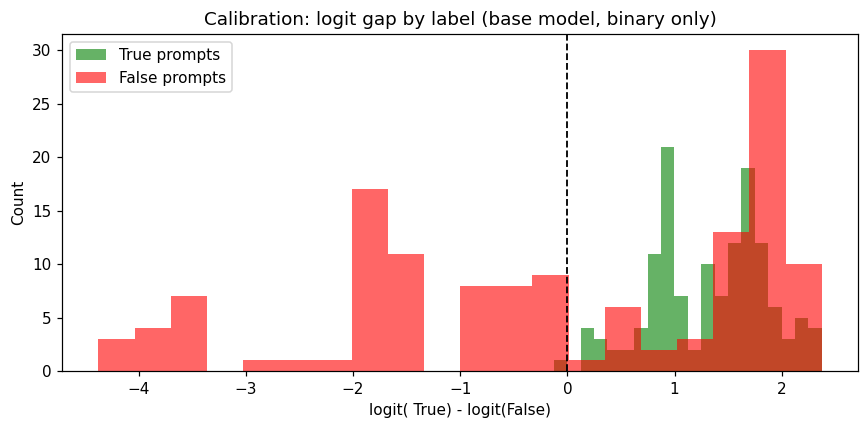

Mann-Whitney U: U=12135.0, p=0.0000
Statistically significant logit gap difference by label.

First-token accuracy by family:
  geometry_claim          : 18/36 = 50.0%
  numeric_validity        : 186/234 = 79.5%


In [6]:
def _safe_label_true(s):
    try:
        return _binary_label_true(s['label'])
    except Exception:
        return None

binary_stats = [s for s in stats if s.get('task_type', 'binary') == 'binary']
gaps_true  = [s['logit_gap'] for s in binary_stats if s.get('logit_gap') is not None and _safe_label_true(s) is True]
gaps_false = [s['logit_gap'] for s in binary_stats if s.get('logit_gap') is not None and _safe_label_true(s) is False]

fig, ax = plt.subplots(figsize=(8, 4))
if gaps_true:
    ax.hist(gaps_true,  bins=20, alpha=0.6, color='green', label='True prompts')
if gaps_false:
    ax.hist(gaps_false, bins=20, alpha=0.6, color='red',   label='False prompts')
ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel("logit( True) - logit(False)")
ax.set_ylabel("Count")
ax.set_title("Calibration: logit gap by label (base model, binary only)")
ax.legend()
plt.tight_layout()
plt.savefig(MY_WORK / "results" / "statistics" / "base_logit_gap.png", bbox_inches="tight")
plt.show()

if gaps_true and gaps_false:
    from scipy import stats as scipy_stats
    stat_val, p_val = scipy_stats.mannwhitneyu(gaps_true, gaps_false, alternative='two-sided')
    print(f"Mann-Whitney U: U={stat_val:.1f}, p={p_val:.4f}")
    if p_val < 0.05:
        print("Statistically significant logit gap difference by label.")
    else:
        print("No significant logit gap difference by label (expected -- supervisor found ~0.55 accuracy).")

print()
print("First-token accuracy by family:")
fam_totals: dict = {}
for s in binary_stats:
    fam = s.get('family', '?')
    correct = _is_correct(s)
    if fam not in fam_totals:
        fam_totals[fam] = [0, 0]
    fam_totals[fam][0] += int(correct)
    fam_totals[fam][1] += 1
for fam, (n_ok, n_total) in sorted(fam_totals.items()):
    print(f"  {fam:<24}: {n_ok}/{n_total} = {n_ok/n_total:.1%}")

**What we measured**
For each binary prompt, we examine how strongly the model favors answering "True" over "False" using the logit gap:
$$
\log\big(\mathrm{prob}(\mathrm{True})\big) - \log\big(\mathrm{prob}(\mathrm{False})\big)
$$
Positive values mean the mass is on "True", negative values mean the mass is on "False".
The histogram compares ground-truth True vs. ground-truth False prompts.

**Mann–Whitney U test:**
$$
U = 12135,\, p \approx 0
$$
— the two label groups do not share the same distribution of this gap.
In plain terms: True-labelled and False-labelled items systematically differ in how the model tilts between True and False, not just by random noise.

**What the plot suggests (read together with the test):**
- True prompts sit mostly on the positive side: the model usually assigns higher probability to "True" when the answer really is True.
- False prompts are split: some correctly push mass toward False (negative gap), but many sit on the positive side with high gaps — i.e., the model is often confident in "True" even when the correct answer is False. That pattern matches a strong True bias and substantial overlap between the two curves on the right of the decision line (gap $=0$).
So: the test says the groups are different; the picture says they are not cleanly separated — especially because many false items look like true items in terms of this score.

**First-token accuracy by family**

| Family          | Accuracy         | Comment (informal)                                                                                                   |
|-----------------|-----------------|---------------------------------------------------------------------------------------------------------------------|
| geometry_claim  | 18/36 = 50.0%   | At chance for 50/50 binary; consistent with the bias and overlap above for abstract statements.                     |
| numeric_validity| 186/234 = 79.5% | Much easier slice: concrete side-length style claims line up better with token-level Truth/False.                    |

Takeaway: On this probe, numeric validity behaves like a tractable factual task under the headline metric, while geometry claims look miscalibrated and near random, which fits a model that systematically leans True and confuses abstract true/false geometry wording.

## 3b — Prune-curve and top-K=20 diagnostics

Visual checks for the supervisor-requested fingerprint metrics.

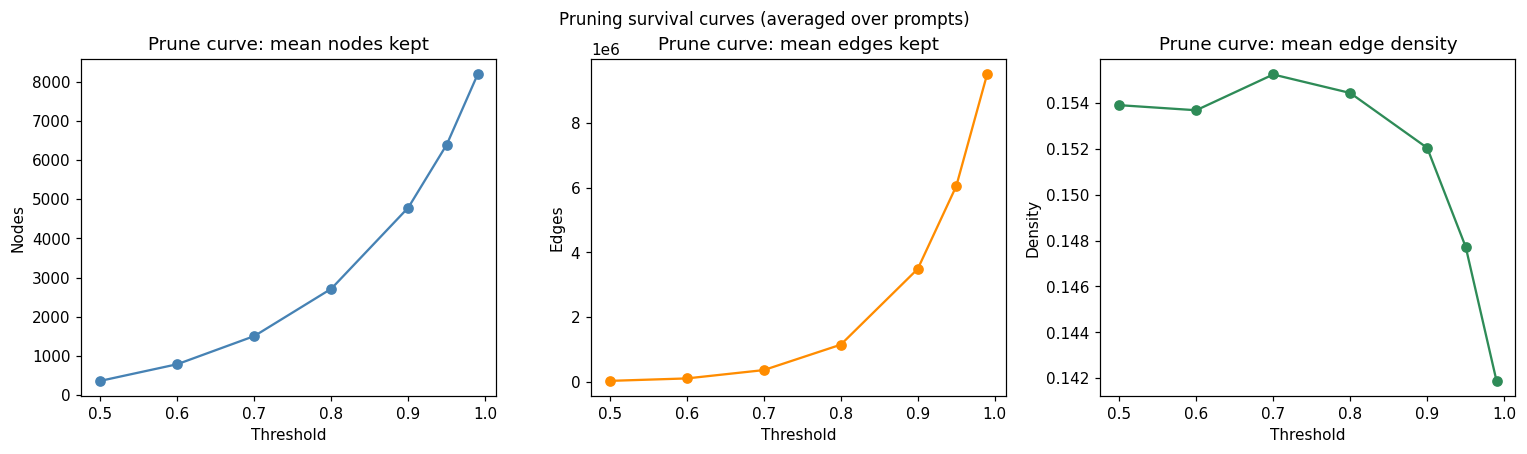

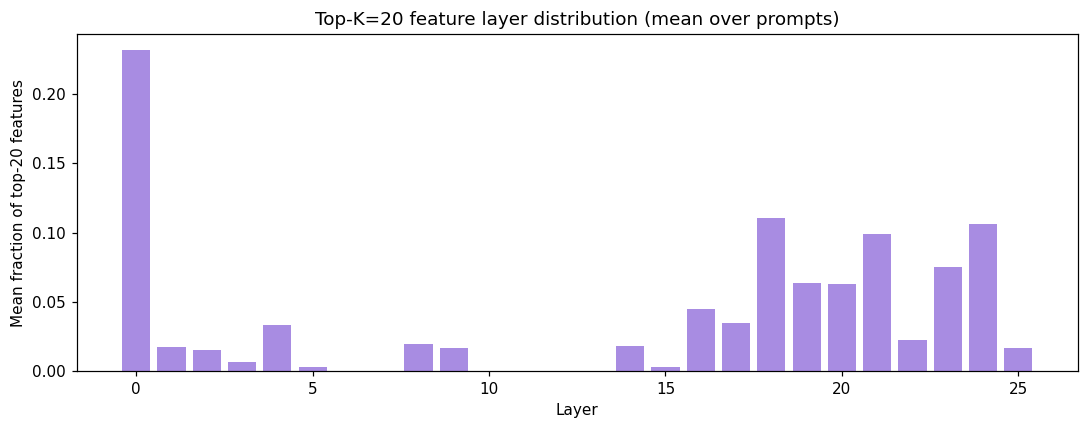

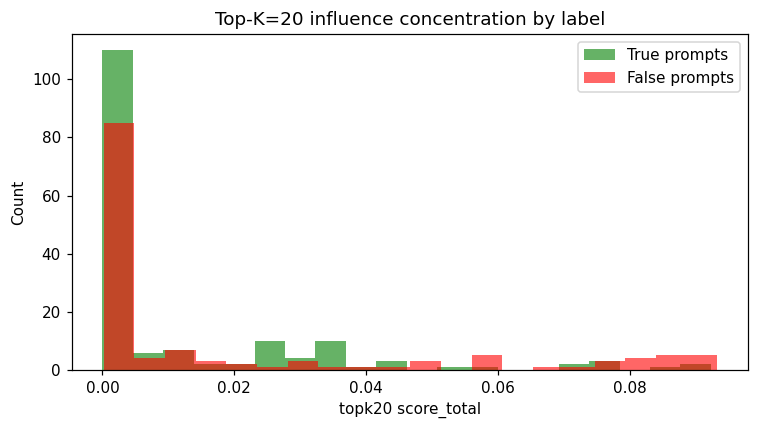

In [7]:
# ── Prune-curve: mean node/edge counts per threshold across all prompts ────────
all_curves = [s.get("prune_curve") for s in stats if s.get("prune_curve")]
if all_curves:
    from collections import defaultdict
    bucket: dict = defaultdict(lambda: {"nodes": [], "edges": [], "density": []})
    for curve in all_curves:
        for pt in curve:
            t = pt["threshold"]
            if pt["n_nodes_kept"] is not None:
                bucket[t]["nodes"].append(pt["n_nodes_kept"])
            if pt["n_edges_kept"] is not None:
                bucket[t]["edges"].append(pt["n_edges_kept"])
            if pt["edge_density"] is not None:
                bucket[t]["density"].append(pt["edge_density"])

    thresholds = sorted(bucket.keys())
    mean_nodes   = [np.mean(bucket[t]["nodes"])   if bucket[t]["nodes"]   else np.nan for t in thresholds]
    mean_edges   = [np.mean(bucket[t]["edges"])   if bucket[t]["edges"]   else np.nan for t in thresholds]
    mean_density = [np.mean(bucket[t]["density"]) if bucket[t]["density"] else np.nan for t in thresholds]

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))
    ax1.plot(thresholds, mean_nodes,   marker='o', color='steelblue')
    ax1.set_title("Prune curve: mean nodes kept"); ax1.set_xlabel("Threshold"); ax1.set_ylabel("Nodes")
    ax2.plot(thresholds, mean_edges,   marker='o', color='darkorange')
    ax2.set_title("Prune curve: mean edges kept"); ax2.set_xlabel("Threshold"); ax2.set_ylabel("Edges")
    ax3.plot(thresholds, mean_density, marker='o', color='seagreen')
    ax3.set_title("Prune curve: mean edge density"); ax3.set_xlabel("Threshold"); ax3.set_ylabel("Density")
    plt.tight_layout()
    plt.suptitle("Pruning survival curves (averaged over prompts)", y=1.02, fontsize=11)
    plt.savefig(MY_WORK / "results" / "statistics" / "base_prune_curves.png", bbox_inches="tight")
    plt.show()
else:
    print("No prune_curve data found in stats — was 02 run with the updated graph_statistics.py?")

# ── Top-K=20 layer histogram: mean distribution across prompts ─────────────────
from utils.graph_statistics import N_LAYERS
layer_hists = [s["topk20"]["layer_hist"] for s in stats if s.get("topk20")]
if layer_hists:
    mean_lh = np.mean(np.array(layer_hists), axis=0)  # shape (26,)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(range(N_LAYERS), mean_lh, color='mediumpurple', alpha=0.8)
    ax.set_xlabel("Layer"); ax.set_ylabel("Mean fraction of top-20 features")
    ax.set_title("Top-K=20 feature layer distribution (mean over prompts)")
    plt.tight_layout()
    plt.savefig(MY_WORK / "results" / "statistics" / "base_topk20_layer_hist.png", bbox_inches="tight")
    plt.show()

    # score_total distribution by label
    totals_true  = [s["topk20"]["score_total"] for s in stats if s.get("topk20") and s["label"]]
    totals_false = [s["topk20"]["score_total"] for s in stats if s.get("topk20") and not s["label"]]
    fig, ax = plt.subplots(figsize=(7, 4))
    if totals_true:
        ax.hist(totals_true,  bins=20, alpha=0.6, color='green', label='True prompts')
    if totals_false:
        ax.hist(totals_false, bins=20, alpha=0.6, color='red',   label='False prompts')
    ax.set_xlabel("topk20 score_total"); ax.set_ylabel("Count")
    ax.set_title("Top-K=20 influence concentration by label")
    ax.legend()
    plt.tight_layout()
    plt.savefig(MY_WORK / "results" / "statistics" / "base_topk20_score_by_label.png", bbox_inches="tight")
    plt.show()
else:
    print("No topk20 data found.")

These three panels show how the attribution graph changes as the node pruning threshold is swept from 0.5 to 1.0, with the edge prune setting held fixed (edge threshold fixed at 0.99 following the protocol in `graph_statistics.py`; each point is averaged across prompts).

**Mean nodes kept:**  
The left curve rises monotonically: a higher threshold keeps more nodes in the graph. The jump is mild at first, then accelerates toward 1.0 (from on the order of hundreds of nodes at the low end to thousands toward 1.0 in your figure). So, the bulk of the attribution graph is only included once the threshold is set very high; strict cuts leave a small core subgraph.
 
**Mean edges kept:**  
The middle curve also grows as the threshold increases, but much more steeply than nodes. That's expected: with ≈ $n$ nodes, the maximum possible number of directed edges scales like **$n(n-1)$**. As $n$ grows, the number of possible edges explodes, so allowed edges (after the fixed edge rule) can ramp up faster than linearly with node count — which manifests as counts on the order of millions late in the sweep.
 
**Mean edge density among kept nodes:**  
The right panel moves downward as threshold increases. Here, density is “edges kept divided by the number of possible edges between kept nodes”, i.e.,  
edge density = $\dfrac{\text{edges kept}}{n(n-1)}$

where $n$ is number of nodes kept. So:
- At low thresholds, you keep a small, tight set of nodes → relatively many of the possible pairwise links are present → higher density.
- At high thresholds, you add many extra nodes → the denominator $n(n-1)$ grows quadratically, while edges do not keep the same proportion → average edge presence per possible link drops → lower density.
 
The curves are consistent: you are not adding a uniform random clique; you are thickening the subgraph in a way where new nodes are more weakly linked (or are likelier to fail the edge mask) than the early, high-salience core.
 
**One-sentence takeaway:**  
Stricter inclusion of nodes (moving right on the axis) inflates graph size and edge count, but the kept graph becomes sparser in a relative sense: a small dense core at low threshold, a large, dilute graph at high threshold.

## 4 — First-token behaviour (baseline v2)

Exports from **`02_baseline_attribution.ipynb` §4 and §4b** live under **`my_work/results/first_token/`**:

- **`base_v2_predictions.csv`** — argmax of the **full vocabulary** vs the gold True/False or digit token.
- **`base_v2_binary_token_probs.csv`** — softmax probabilities on **` True`** and **` False`** tokens only at the last position.

This section separates **binary** prompts (truth judgements about triangle sides or abstract geometry) from **numeric** open questions (min/max third side). For binary items we break down performance by **geometry vs numeric validity** wording and by **affirmative “possible / can” vs negated “not possible / cannot”** phrasing (`claim_direction`). Abstract geometry prompts have **no `claim_direction`** in the probe — they appear as their own polarity bucket.

For numeric prompts, raw argmax digit accuracy is known to be poor; we additionally score each row with **`P(correct digit) − Σ P(other digits)`** over the monitored digit tokens (mass not on those ten digits is implicitly “other”) to see whether the correct digit is ever favoured *relative to the competing digits*.

### 4.1 Load probe metadata and CSV exports

We join everything on **`prompt_id`**. Probe fields **`family`** and **`claim_direction`** drive the breakdowns below.

If a CSV is missing locally, rerun **`02`** through §4b on the machine that produces **`base_v2_*.csv`** files.

In [8]:
import json

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

FIRST_TOKEN_DIR = MY_WORK / "results" / "first_token"
PROBE_PATH = MY_WORK / "data" / "prompts_triangle_v2.jsonl"

_pred_path = FIRST_TOKEN_DIR / "base_v2_predictions.csv"
_bin_prob_path = FIRST_TOKEN_DIR / "base_v2_binary_token_probs.csv"
_num_prob_path = FIRST_TOKEN_DIR / "base_v2_numeric_digit_probs.csv"

for _p in (_pred_path, _bin_prob_path, _num_prob_path):
    if not _p.exists():
        raise FileNotFoundError(
            f"Missing {_p}\nRun 02_baseline_attribution.ipynb §4 (accuracy) and §4b (prob tables)."
        )

# Probe metadata slice we need downstream
_probe_rows = []
with open(PROBE_PATH, "r", encoding="utf-8") as _f:
    for _line in _f:
        _line = _line.strip()
        if not _line:
            continue
        _o = json.loads(_line)
        _probe_rows.append(
            {
                "prompt_id": _o["prompt_id"],
                "family": _o.get("family"),
                "claim_direction": _o.get("claim_direction"),
                "open_kind": _o.get("open_kind"),
                "task_type": _o.get("task_type", "binary"),
                "tail": _o.get("tail"),
            }
        )
probe_meta = pd.DataFrame(_probe_rows)


def polarity_label(row) -> str:
    """Rough 'can vs cannot' split for numeric prompts; geometry is separate."""
    if row["family"] == "geometry_claim":
        return "abstract_geometry"
    cd = row["claim_direction"]
    if cd == "possible":
        return "possible / can-affirmative"
    if cd == "not_possible":
        return "not_possible / cannot-style"
    return "(other)"

def question_stream(row) -> str:
    return "geometry_claim" if row["family"] == "geometry_claim" else "numeric_validity"


pred = pd.read_csv(_pred_path)
bin_prob = pd.read_csv(_bin_prob_path)
num_prob = pd.read_csv(_num_prob_path)

# Harmonise dtypes
pred["is_correct"] = pred["is_correct"].astype(bool)

_bin_pred = pred[pred["task_type"] == "binary"][
    [
        "prompt_id",
        "is_correct",
        "expected_response",
        "argmax_response",
        "expected_token_id",
        "argmax_token_id",
    ]
].copy()

bin_df = bin_prob.merge(
    probe_meta[["prompt_id", "claim_direction", "open_kind"]],
    on="prompt_id",
    how="left",
).merge(_bin_pred, on="prompt_id", how="inner")


def _truth_tf(x):
    if isinstance(x, (bool, np.bool_)):
        return bool(x)
    return str(x).strip().lower() in ("true", "1")


bin_df["truth_true"] = bin_df["label"].map(_truth_tf)

bin_df["p_correct_tf"] = np.where(bin_df["truth_true"], bin_df["prob_true"], bin_df["prob_false"])
bin_df["p_wrong_tf"] = np.where(bin_df["truth_true"], bin_df["prob_false"], bin_df["prob_true"])
bin_df["tf_margin_softmax"] = bin_df["p_correct_tf"] - bin_df["p_wrong_tf"]
bin_df["softmax_tf_favours_truth"] = bin_df["tf_margin_softmax"] > 0

bin_df["polarity"] = bin_df.apply(polarity_label, axis=1)
bin_df["stream"] = bin_df.apply(question_stream, axis=1)


def grp_key(r) -> str:
    if r["stream"] == "geometry_claim":
        return "geom · abstract"
    if r["polarity"].startswith("possible"):
        return "numeric · affirmative (possible)"
    if r["polarity"].startswith("not_possible"):
        return "numeric · negated (not possible)"
    return "numeric · (other)"

bin_df["group_label"] = bin_df.apply(grp_key, axis=1)

DIGIT_COLS = [f"prob_digit_{d}" for d in range(10)]

num_df = num_prob.merge(
    probe_meta[["prompt_id", "claim_direction", "open_kind"]],
    on="prompt_id",
    how="left",
)

num_pred = pred[pred["task_type"] == "numeric"][
    ["prompt_id", "is_correct", "expected_token_id", "argmax_token_id"]
].copy()

num_df = num_df.merge(num_pred, on="prompt_id", how="inner")

_lbl = pd.to_numeric(num_df["label"], errors="raise").astype(int).to_numpy()
_digit_mat = num_df[DIGIT_COLS].to_numpy(dtype=float)
_r = np.arange(len(num_df))
_p_correct_digit = _digit_mat[_r, _lbl]
mass = num_df["prob_mass_digits"].to_numpy(dtype=float)

# P(correct digit) − Σ P(other digits monitored)  ==  2·P(correct) − Σ_{0–9}
num_df["_digit_margin"] = 2.0 * _p_correct_digit - mass






print("Binary rows (merged):", len(bin_df))
print("Numeric rows (merged):", len(num_df))
print("\nBinary group counts:")
print(bin_df["group_label"].value_counts().sort_index())

Binary rows (merged): 270
Numeric rows (merged): 30

Binary group counts:
group_label
geom · abstract                      36
numeric · affirmative (possible)    129
numeric · negated (not possible)    105
Name: count, dtype: int64


### 4.2 Binary prompts — hard argmax vs True/Only softmax lane

Two different readouts:

1. **Hard argmax (§4 CSV)** — the model picks the highest-probability token over the **whole vocabulary**. It may be whitespace, newline, or “Yes” instead of **` True`** even when **` True`**/` False` are plausible.

2. **Two-token softmax lane (§4b CSV)** — we read off **`prob_true`** and **`prob_false`** only. Define **`tf_margin`** = (**probability on the gold token**) − (**probability on the opposite token**) within those two masses. **`tf_margin > 0`** means that *narrow* metric already favours the correct answer—even if overall argmax is wrong.

Plots: bar chart of subgroup accuracies vs fraction with **`tf_margin > 0`**, and **`prob_true` vs `prob_false`** scatter coded by correctness.

Binary first-token summary (by subgroup):
                     group_label   n argmax_acc softmax_truth_rate mean_tf_margin
                 geom · abstract  36      16.7%              50.0%        -0.0002
numeric · affirmative (possible) 129      13.2%              89.9%         0.0303
numeric · negated (not possible) 105      25.7%              65.7%         0.0283


/var/folders/55/jy9y5nzj7qs7v5_w96z37dm00000gp/T/ipykernel_94231/2531928759.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _cmap = plt.cm.get_cmap("tab10")


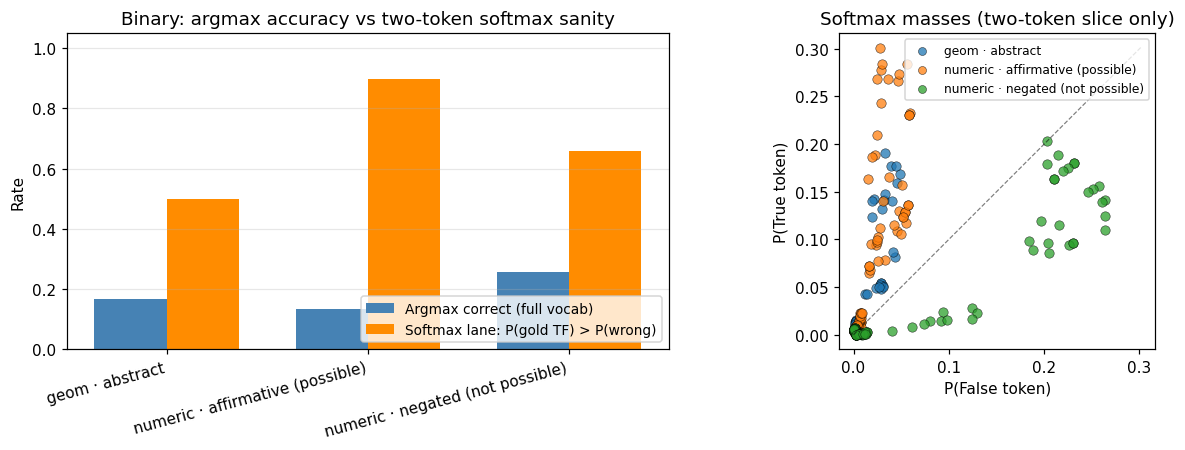

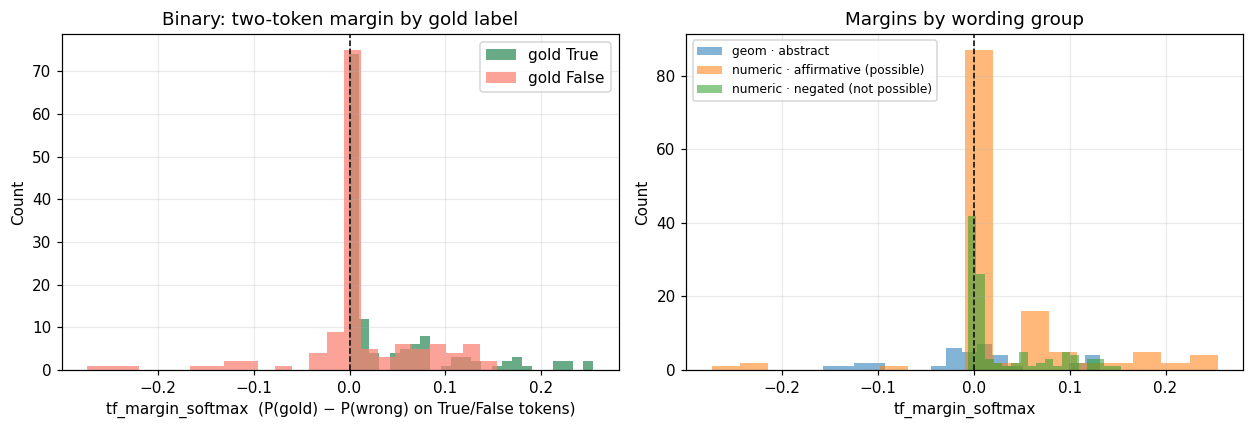

In [9]:
# ── Binary summaries ───────────────────────────────────────────────────────────
_agg = (
    bin_df.groupby("group_label", sort=True)
    .agg(
        n=("prompt_id", "count"),
        argmax_acc=("is_correct", "mean"),
        softmax_truth_rate=("softmax_tf_favours_truth", "mean"),
        mean_tf_margin=("tf_margin_softmax", "mean"),
    )
    .reset_index()
)

print("Binary first-token summary (by subgroup):")
print(_agg.to_string(index=False, formatters={"argmax_acc": "{:.1%}".format, "softmax_truth_rate": "{:.1%}".format, "mean_tf_margin": "{:.4f}".format}))

_groups = list(_agg["group_label"])
_x = np.arange(len(_groups))
_w = 0.36

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax0 = axes[0]
ax0.bar(_x - _w / 2, _agg["argmax_acc"].to_numpy(), width=_w, label="Argmax correct (full vocab)", color="steelblue")
ax0.bar(_x + _w / 2, _agg["softmax_truth_rate"].to_numpy(), width=_w, label="Softmax lane: P(gold TF) > P(wrong)", color="darkorange")
ax0.set_xticks(_x)
ax0.set_xticklabels(_groups, rotation=15, ha="right")
ax0.set_ylim(0, 1.05)
ax0.set_ylabel("Rate")
ax0.set_title("Binary: argmax accuracy vs two-token softmax sanity")
ax0.legend(loc="lower right", fontsize=9)
ax0.grid(axis="y", alpha=0.3)

ax1 = axes[1]
_cmap = plt.cm.get_cmap("tab10")
_palette = [_cmap(i % 10) for i in range(len(_groups))]
for _g, _c in zip(_groups, _palette):
    _m = bin_df["group_label"] == _g
    ax1.scatter(
        bin_df.loc[_m, "prob_false"],
        bin_df.loc[_m, "prob_true"],
        s=38,
        alpha=0.75,
        label=_g,
        color=_c,
        edgecolors="black",
        linewidths=0.35,
    )
mn = float(min(bin_df["prob_false"].min(), bin_df["prob_true"].min()))
mx = float(max(bin_df["prob_false"].max(), bin_df["prob_true"].max()))
ax1.plot([mn, mx], [mn, mx], "k--", lw=0.8, alpha=0.5)
ax1.set_xlabel("P(False token)")
ax1.set_ylabel("P(True token)")
ax1.set_title("Softmax masses (two-token slice only)")
ax1.legend(markerscale=0.85, fontsize=8, loc="best")
ax1.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.savefig(MY_WORK / "results" / "statistics" / "base_first_token_binary_breakdown.png", dpi=140, bbox_inches="tight")
plt.show()

fig2, axs = plt.subplots(1, 2, figsize=(11.5, 4.0))
_truth = bin_df[bin_df["truth_true"]]
_false = bin_df[~bin_df["truth_true"]]
axs[0].hist(_truth["tf_margin_softmax"].clip(-3, 3), bins=24, alpha=0.72, label="gold True", color="seagreen")
axs[0].hist(_false["tf_margin_softmax"].clip(-3, 3), bins=24, alpha=0.72, label="gold False", color="salmon")
axs[0].axvline(0, color="black", linestyle="--", lw=1)
axs[0].set_xlabel("tf_margin_softmax  (P(gold) − P(wrong) on True/False tokens)")
axs[0].set_ylabel("Count")
axs[0].set_title("Binary: two-token margin by gold label")
axs[0].legend()
axs[0].grid(alpha=0.25)

for _g in _groups:
    _m = bin_df["group_label"] == _g
    axs[1].hist(
        bin_df.loc[_m, "tf_margin_softmax"].clip(-3, 3),
        bins=18,
        alpha=0.55,
        label=_g,
    )
axs[1].axvline(0, color="black", linestyle="--", lw=1)
axs[1].set_xlabel("tf_margin_softmax")
axs[1].set_ylabel("Count")
axs[1].set_title("Margins by wording group")
axs[1].legend(fontsize=8)
axs[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(MY_WORK / "results" / "statistics" / "base_first_token_binary_margins.png", dpi=140, bbox_inches="tight")
plt.show()


**What the table is saying**

For each subgroup we report: hard argmax over the whole vocabulary, the narrow check that P(gold TF token) > P(other TF token), and mean_tf_margin = that same gap averaged in probability space.

- **Argmax** stays in the teens–mid‑20% everywhere: the model’s top-1 token is usually not True or False (newlines, fillers, other words eat most of the mass).

- The two-token **softmax** lane is different: we only ask which of the two supervised answer tokens is bigger. That can be “sane” even when neither token wins globally.

**Summary Table**

| **Subgroup**           | **Argmax** | **Softmax lane** | **Mean margin** | **Plain English**                                                                                                   |
|:----------------------:|:----------:|:---------------:|:---------------:|:--------------------------------------------------------------------------------------------------------------------|
| geom · abstract        | 16.7%      | 50.0%           | ≈ 0             | Almost no dedicated mass on True/False (scatter hugs the origin). Gold True/False are mirror images; coin flip win. |
| numeric · affirmative  | 13.2%      | 89.9%           | +0.03           | Typical: high P(True) vs tiny P(False). Model leans True on "possible/can" wordings; narrow softmax agrees often.   |
| numeric · negated      | 25.7%      | 65.7%           | +0.03           | Cloud shifts: higher P(False) for many. Lean False on "not possible/cannot" prompts, but not always.                |

**One-sentence takeaway:**

The full-vocabulary argmax underestimates model performance across all three groups, but for different reasons in each case. In the geometry group, the model displays no consistent preference for True or False (narrow accuracy remains at 50%, with margins around zero), suggesting little to no signal for these tokens. In contrast, for numeric validity questions, there is a clear bias driven by the structure of the prompts: affirmative questions tend to favor **True**, while negated questions lean towards **False**. This bias is evident in the two-token comparison, even though the majority of probability mass always remains outside the answer tokens.

### 4.3 Numeric prompts — argmax misses but digit mass is diffuse

Digit questions reuse the *Answer:* open template as in the probe. **Argmax** over the vocabulary still usually lands outside the ASCII digit tokens—that is why is_correct is historically ~0.

For each prompt we summarize the **tracked digit slice** ${p_0, \ldots, p_9}$ produced in §4b. Let $\Sigma = \sum_k p_k$. The quantity

$$
\text{digit\_margin} = p_{\text{correct}} - \sum_{k \neq \text{correct}} p_k = 2p_{\text{correct}} - \Sigma
$$

is **positive** exactly when **more softmax mass lands on the correct digit id than on the nine incorrect digit ids combined** (among these ten tracked ids). Values near zero indicate the classifier is ambiguous even within digits; negatives mean the incorrect digits collectively outweigh the truth.

Plots: overall argmax accuracy, histogram + strip of *digit_margin* by *open_kind*, and jittered scatter vs *is_correct*.

Numeric prompts — argmax correctness: 0 / 30 = 0.0%
Fraction with digit_margin > 0 ("correct beats other nine summed"): 0.0%

By question template (open_kind):
open_kind  n argmax_hit mean_margin frac_margin_pos
max_third 15       0.0%     -0.0047            0.0%
min_third 15       0.0%     -0.0040            0.0%


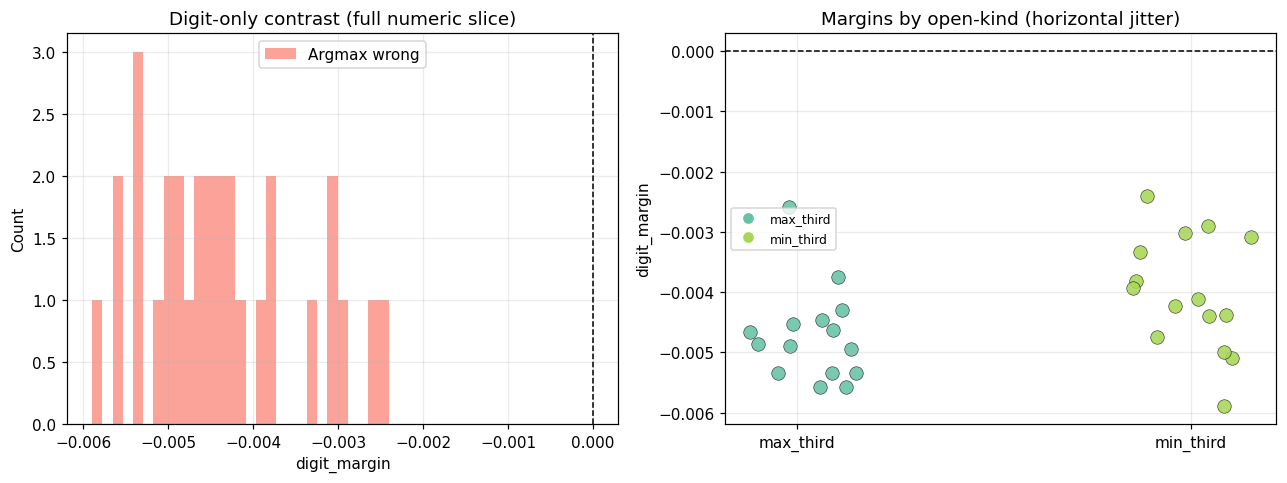

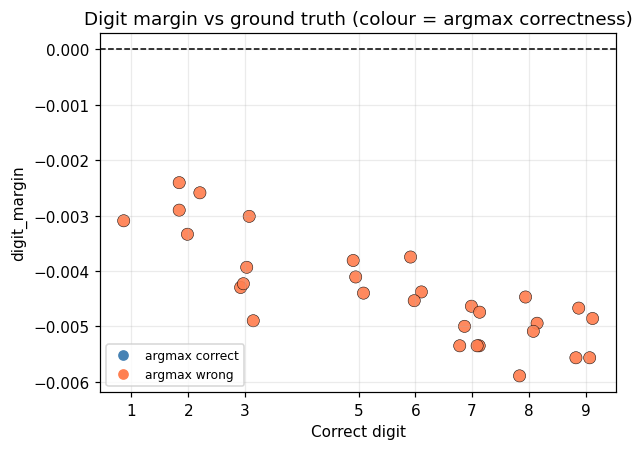

In [10]:
# ── Numeric summaries ──────────────────────────────────────────────────────────
_n = len(num_df)
_acc = float(num_df["is_correct"].mean()) if _n else 0.0
_pos_margin = float((num_df["_digit_margin"] > 0).mean()) if _n else 0.0

print(f"Numeric prompts — argmax correctness: {num_df['is_correct'].sum()} / {_n} = {_acc:.1%}")
print(f'Fraction with digit_margin > 0 ("correct beats other nine summed"): {_pos_margin:.1%}')
print()

_by_ok = (
    num_df.groupby("open_kind")
    .agg(
        n=("prompt_id", "count"),
        argmax_hit=("is_correct", "mean"),
        mean_margin=("_digit_margin", "mean"),
        frac_margin_pos=("_digit_margin", lambda s: float((s > 0).mean())),
    )
    .reset_index()
)

print("By question template (open_kind):")
print(
    _by_ok.to_string(
        index=False,
        formatters={"argmax_hit": "{:.1%}".format, "mean_margin": "{:.4f}".format, "frac_margin_pos": "{:.1%}".format},
    )
)

_rng = np.random.default_rng(42)

fig_a, axes = plt.subplots(1, 2, figsize=(11.8, 4.5))

_lo, hi = float(num_df["_digit_margin"].min()), float(num_df["_digit_margin"].max())
_hist_bins = np.linspace(_lo - 1e-6, hi + 1e-6, max(14, len(num_df)))

_ok_m = num_df["is_correct"]
if (_ok_m).any():
    axes[0].hist(num_df.loc[_ok_m, "_digit_margin"], bins=_hist_bins, alpha=0.72, label="Argmax OK", color="seagreen")
if (~_ok_m).any():
    axes[0].hist(num_df.loc[~_ok_m, "_digit_margin"], bins=_hist_bins, alpha=0.72, label="Argmax wrong", color="salmon")
axes[0].axvline(0, color="black", linestyle="--", lw=1)
axes[0].set_xlabel("digit_margin")
axes[0].set_ylabel("Count")
axes[0].set_title("Digit-only contrast (full numeric slice)")
axes[0].legend()
axes[0].grid(alpha=0.25)

_ord = sorted(num_df["open_kind"].dropna().astype(str).unique())
_pos = {_k: i for i, _k in enumerate(_ord)}
_cmap_set2 = matplotlib.colormaps.get_cmap("Set2")
_clr = {_k: _cmap_set2(i / max(len(_ord), 1)) for i, _k in enumerate(_ord)}
handles = []

for _, _rw in num_df.iterrows():
    kin = str(_rw["open_kind"])
    xh = float(_pos[kin]) + _rng.uniform(-0.16, 0.16)
    axes[1].scatter(xh, _rw["_digit_margin"], s=78, color=_clr[kin], alpha=0.88, edgecolors="black", linewidths=0.35)

for _k in _ord:
    handles.append(plt.Line2D([], [], marker="o", linestyle="", color=_clr[_k], label=_k))

axes[1].axhline(0, color="black", linestyle="--", lw=1)
axes[1].set_xticks(list(range(len(_ord))))
axes[1].set_xticklabels(_ord)
axes[1].set_ylabel("digit_margin")
axes[1].set_title("Margins by open-kind (horizontal jitter)")
axes[1].grid(alpha=0.25)
axes[1].legend(handles=handles, loc="best", fontsize=8)

plt.tight_layout()
plt.savefig(MY_WORK / "results" / "statistics" / "base_first_token_numeric_digit_margin.png", dpi=140, bbox_inches="tight")
plt.show()

fig_b, axb = plt.subplots(figsize=(5.8, 4.2))
_lab = pd.to_numeric(num_df["label"], errors="coerce").astype(float).to_numpy()

axb.scatter(
    _lab + _rng.uniform(-0.22, 0.22, size=len(num_df)),
    num_df["_digit_margin"],
    c=np.where(num_df["is_correct"].to_numpy(), "steelblue", "coral"),
    s=64,
    edgecolors="black",
    linewidths=0.35,
    alpha=0.92,
)

axb.axhline(0, color="black", linestyle="--", lw=1)
uniq_lbl = sorted(pd.Series(num_df["label"]).astype(int).unique())
axb.set_xticks(uniq_lbl)
axb.set_xlabel("Correct digit")
axb.set_ylabel("digit_margin")
axb.set_title("Digit margin vs ground truth (colour = argmax correctness)")
handles2 = [
    plt.Line2D([], [], linestyle="", marker="o", color="steelblue", label="argmax correct"),
    plt.Line2D([], [], linestyle="", marker="o", color="coral", label="argmax wrong"),
]
axb.legend(handles=handles2, loc="best", fontsize=8)
axb.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(MY_WORK / "results" / "statistics" / "base_first_token_numeric_by_label.png", dpi=140, bbox_inches="tight")
plt.show()


**What the table says**

Argmax over the full vocabulary: 0 / 30 prompts get the gold digit as the single most likely next token. So for this probe format (“…Answer:”), the base model essentially never commits to 0–9 as rank‑1 output; tokens like space or line breaks dominate instead.

**The digit-only score (digit_margin)**

We only look at the ten softmax bins prob_digit_0 … prob_digit_9 and prob_mass_digits (their sum).
digit_margin = P(correct) − Σ P(other monitored digits) is still below zero on every row (0 % above 0). So even after restricting attention to digits, the model assigns more total mass to the nine wrong digits combined than to the correct one. That matches the histogram: everything sits left of zero; the dashed line marks “correct digit narrowly wins among digits,” and nobody crosses it.

**min_third vs max_third**

These are two different numeric question templates we used:
- Smallest possible integer length of the third side of a triangle when two side lengths are fixed. 
- Largest possible integer length of the third side for the same two sides.

Both templates behave the same qualitatively (argmax digits never hit; no positive digit margins). The means (about −0.0040 vs about −0.0047) are both tiny negative shifts on an already tiny digit slice (total digit mass ~0.5–0.7 % in your exports)—so differences between templates are small compared to “model not using digits here at all.”

**One-line takeaway**

Numeric items fail at the observable first token, and the digit subspace alone still prefers wrong-digit combinations over the gold digit; interpreting performance needs generation past the first token or different prompts / training, not tweaks inside this marginal slice alone.


## 4b — Base v2 vs v3: paired **True or False** vs **False or True** endings

**v3** (`prompts_triangle_v3.jsonl`, `stats_base_v3.json`, `base_v3_*` first-token CSVs) is the same **90** binary items as v2’s **`true_or_false`** rows, with only the answer instruction flipped (**“True or False”** → **“False or True”**). Prompt ids align by numeric suffix (`tri_v2_003` ↔ `tri_v3_003`).

This block keeps **only that intersection** and compares:

1. **First-token argmax** (full vocabulary — check `is_correct` carefully).
2. **Two-token True/False softmax** lane (`prob_true` / `prob_false`, margin vs gold).
3. **Charts** mirroring §4.2, split by wording subgroup and **ending variant** (v2 vs v3).
4. **Leave-one-family-out** logistic regression on **graph statistics** (v2 graphs vs v3 graphs separately).


In [11]:
# ── 4b: pair v2 true_or_false ↔ v3 false_or_true (90 items) ─────────────────

import json
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

PROBE_V2 = MY_WORK / "data" / "prompts_triangle_v2.jsonl"
PROBE_V3 = MY_WORK / "data" / "prompts_triangle_v3.jsonl"
STATS_V3 = STATISTICS_DIR / "stats_base_v3.json"
FT_DIR = MY_WORK / "results" / "first_token"

_pred_v2 = pd.read_csv(FT_DIR / "base_v2_predictions.csv")
_pred_v3 = pd.read_csv(FT_DIR / "base_v3_predictions.csv")
_bin_v2 = pd.read_csv(FT_DIR / "base_v2_binary_token_probs.csv")
_bin_v3 = pd.read_csv(FT_DIR / "base_v3_v3_binary_token_probs.csv")

for _path in (PROBE_V2, PROBE_V3, STATS_V3):
    if not Path(_path).exists():
        raise FileNotFoundError(f"Missing {_path}")

if "stats" not in dir() or not stats:
    raise RuntimeError("Run the stats load cell (§1) before §4b — need merged base v2 `stats`.")


def _load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def _pair_suffix(pid: str) -> str:
    return str(pid).split("_")[-1]


def _truth_tf(x):
    if isinstance(x, (bool, np.bool_)):
        return bool(x)
    return str(x).strip().lower() in ("true", "1")


def _grp_key(family, claim_direction) -> str:
    if family == "geometry_claim":
        return "geom · abstract"
    if claim_direction == "possible":
        return "numeric · affirmative (possible)"
    if claim_direction == "not_possible":
        return "numeric · negated (not possible)"
    return "numeric · (other)"


_rows_v2 = {r["prompt_id"]: r for r in _load_jsonl(PROBE_V2) if r.get("tail") == "true_or_false"}
_rows_v3 = {r["prompt_id"]: r for r in _load_jsonl(PROBE_V3) if r.get("tail") == "false_or_true"}
_common = sorted(set(map(_pair_suffix, _rows_v2)) & set(map(_pair_suffix, _rows_v3)))
print(f"Paired suffixes (v2 true_or_false ↔ v3 false_or_true): {len(_common)}")

_pairs = []
for suf in _common:
    pid_v2 = next(k for k in _rows_v2 if _pair_suffix(k) == suf)
    pid_v3 = next(k for k in _rows_v3 if _pair_suffix(k) == suf)
    r2, r3 = _rows_v2[pid_v2], _rows_v3[pid_v3]
    if r2["label"] != r3["label"]:
        raise ValueError(f"label mismatch on suffix {suf}")
    _pairs.append(
        {
            "pair_suffix": suf,
            "prompt_id_v2": pid_v2,
            "prompt_id_v3": pid_v3,
            "family": r2["family"],
            "claim_direction": r2.get("claim_direction"),
            "truth_true": _truth_tf(r2["label"]),
            "group_label": _grp_key(r2["family"], r2.get("claim_direction")),
        }
    )

pairs_df = pd.DataFrame(_pairs)

# ── First-token tables ───────────────────────────────────────────────────────
_pred_v2 = _pred_v2.assign(phase="v2 (True or False)")
_pred_v3 = _pred_v3.assign(phase="v3 (False or True)")
_pred_v2["is_correct"] = _pred_v2["is_correct"].astype(bool)
_pred_v3["is_correct"] = _pred_v3["is_correct"].astype(bool)

pr_v2 = pairs_df.merge(
    _pred_v2[["prompt_id", "is_correct", "expected_response", "argmax_response"]],
    left_on="prompt_id_v2",
    right_on="prompt_id",
    how="left",
).rename(columns={"is_correct": "argmax_ok_v2", "expected_response": "exp_v2", "argmax_response": "arg_v2"})

pr_v3 = pairs_df.merge(
    _pred_v3[["prompt_id", "is_correct", "expected_response", "argmax_response"]],
    left_on="prompt_id_v3",
    right_on="prompt_id",
    how="left",
).rename(columns={"is_correct": "argmax_ok_v3", "expected_response": "exp_v3", "argmax_response": "arg_v3"})

bp_v2 = pairs_df.merge(
    _bin_v2[["prompt_id", "prob_true", "prob_false"]],
    left_on="prompt_id_v2",
    right_on="prompt_id",
    how="left",
)
bp_v3 = pairs_df.merge(
    _bin_v3[["prompt_id", "prob_true", "prob_false"]],
    left_on="prompt_id_v3",
    right_on="prompt_id",
    how="left",
)

paired_ft = pairs_df.copy()
paired_ft["argmax_ok_v2"] = pr_v2["argmax_ok_v2"].to_numpy()
paired_ft["argmax_ok_v3"] = pr_v3["argmax_ok_v3"].to_numpy()
paired_ft["prob_true_v2"] = bp_v2["prob_true"].to_numpy()
paired_ft["prob_false_v2"] = bp_v2["prob_false"].to_numpy()
paired_ft["prob_true_v3"] = bp_v3["prob_true"].to_numpy()
paired_ft["prob_false_v3"] = bp_v3["prob_false"].to_numpy()

for _phase in ("v2", "v3"):
    _tt = paired_ft["truth_true"]
    paired_ft[f"p_correct_{_phase}"] = np.where(
        _tt,
        paired_ft[f"prob_true_{_phase}"],
        paired_ft[f"prob_false_{_phase}"],
    )
    paired_ft[f"tf_margin_{_phase}"] = (
        paired_ft[f"p_correct_{_phase}"]
        - np.where(
            _tt,
            paired_ft[f"prob_false_{_phase}"],
            paired_ft[f"prob_true_{_phase}"],
        )
    )
    paired_ft[f"softmax_ok_{_phase}"] = paired_ft[f"tf_margin_{_phase}"] > 0

# Long form for plotting
_long_rows = []
for _, r in paired_ft.iterrows():
    for phase, ending in (
        ("v2 (True or False)", "true_or_false"),
        ("v3 (False or True)", "false_or_true"),
    ):
        _long_rows.append(
            {
                "pair_suffix": r["pair_suffix"],
                "group_label": r["group_label"],
                "family": r["family"],
                "ending": ending,
                "phase": phase,
                "truth_true": r["truth_true"],
                "argmax_ok": r[f"argmax_ok_{phase[0:2]}"],
                "softmax_ok": r[f"softmax_ok_{phase[0:2]}"],
                "tf_margin": r[f"tf_margin_{phase[0:2]}"],
                "prob_true": r[f"prob_true_{phase[0:2]}"],
                "prob_false": r[f"prob_false_{phase[0:2]}"],
            }
        )
paired_long = pd.DataFrame(_long_rows)

print("\nPaired first-token summary (by subgroup × ending variant):")
_summary = (
    paired_long.groupby(["group_label", "phase"], sort=True)
    .agg(
        n=("pair_suffix", "count"),
        argmax_acc=("argmax_ok", "mean"),
        softmax_truth_rate=("softmax_ok", "mean"),
        mean_tf_margin=("tf_margin", "mean"),
    )
    .reset_index()
)
print(
    _summary.to_string(
        index=False,
        formatters={
            "argmax_acc": "{:.1%}".format,
            "softmax_truth_rate": "{:.1%}".format,
            "mean_tf_margin": "{:.4f}".format,
        },
    )
)

print("\nOverall paired (n=90):")
for phase in paired_long["phase"].unique():
    sub = paired_long[paired_long["phase"] == phase]
    print(
        f"  {phase}: argmax {sub['argmax_ok'].mean():.1%} | "
        f"softmax lane {sub['softmax_ok'].mean():.1%} | "
        f"mean margin {sub['tf_margin'].mean():.4f}"
    )



Paired suffixes (v2 true_or_false ↔ v3 false_or_true): 90

Paired first-token summary (by subgroup × ending variant):
                     group_label              phase  n argmax_acc softmax_truth_rate mean_tf_margin
                 geom · abstract v2 (True or False) 12       0.0%              50.0%         0.0001
                 geom · abstract v3 (False or True) 12       0.0%              50.0%        -0.0001
numeric · affirmative (possible) v2 (True or False) 43       0.0%              90.7%         0.0032
numeric · affirmative (possible) v3 (False or True) 43       0.0%              90.7%         0.0052
numeric · negated (not possible) v2 (True or False) 35       0.0%               0.0%        -0.0047
numeric · negated (not possible) v3 (False or True) 35       0.0%               0.0%        -0.0060

Overall paired (n=90):
  v2 (True or False): argmax 0.0% | softmax lane 50.0% | mean margin -0.0003
  v3 (False or True): argmax 0.0% | softmax lane 50.0% | mean margin 0.0001


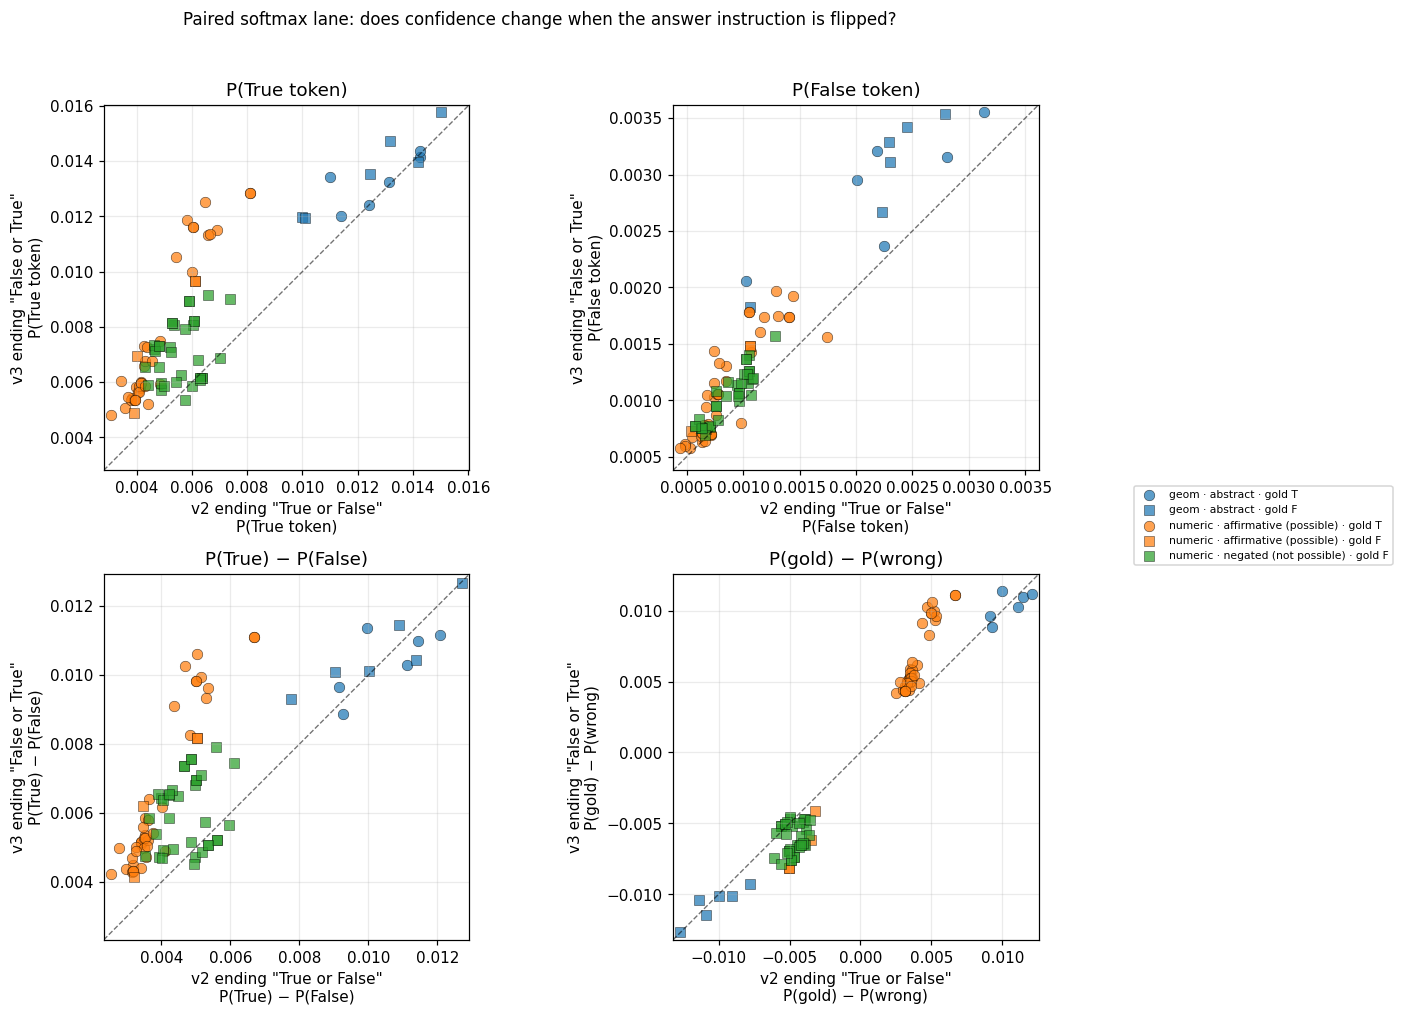

Saved /Users/Lacus/Documents/ELTE/Thesis/circuit-tracer-main/my_work/results/statistics/paired_v2_v3_softmax_confidence_scatter.png
P(True token)                 r=+0.860  mean|Δ|=0.0021  max|Δ|=0.0060
P(False token)                r=+0.952  mean|Δ|=0.0003  max|Δ|=0.0010
P(True) − P(False)            r=+0.790  mean|Δ|=0.0019  max|Δ|=0.0056
P(gold) − P(wrong)            r=+0.970  mean|Δ|=0.0019  max|Δ|=0.0056


In [23]:
# ── 4b: softmax confidence v2 vs v3 (paired 90) ───────────────────────────────
# X = "True or False" ending (v2); Y = "False or True" ending (v3). Points on the
# diagonal y=x mean unchanged two-token mass; off-diagonal = flip sensitivity.
# tf_bias = P(True)−P(False) (always favours-True mass); tf_margin = P(gold)−P(wrong).

if "paired_ft" not in dir() or paired_ft.empty:
    raise RuntimeError("Run the pairing cell above first (needs `paired_ft`).")

_df = paired_ft.copy()
_df["tf_bias_v2"] = _df["prob_true_v2"] - _df["prob_false_v2"]
_df["tf_bias_v3"] = _df["prob_true_v3"] - _df["prob_false_v3"]
_groups = sorted(_df["group_label"].unique())
_cmap = matplotlib.colormaps.get_cmap("tab10")
_palette = {g: _cmap(i % 10) for i, g in enumerate(_groups)}
_mark = {True: "o", False: "s"}

fig, axes = plt.subplots(2, 2, figsize=(10.5, 9))
axes = axes.ravel()

_panels = [
    ("prob_true_v2", "prob_true_v3", "P(True token)"),
    ("prob_false_v2", "prob_false_v3", "P(False token)"),
    ("tf_bias_v2", "tf_bias_v3", "P(True) − P(False)"),
    ("tf_margin_v2", "tf_margin_v3", "P(gold) − P(wrong)"),
]

for ax, (xc, yc, title) in zip(axes, _panels):
    lo = float(min(_df[xc].min(), _df[yc].min()))
    hi = float(max(_df[xc].max(), _df[yc].max()))
    pad = 0.02 * (hi - lo) if hi > lo else 0.01
    lo, hi = lo - pad, hi + pad

    for g in _groups:
        m = _df["group_label"] == g
        for gold in (True, False):
            m2 = m & (_df["truth_true"] == gold)
            if not m2.any():
                continue
            ax.scatter(
                _df.loc[m2, xc],
                _df.loc[m2, yc],
                s=48,
                alpha=0.72,
                color=_palette[g],
                marker=_mark[gold],
                edgecolors="black",
                linewidths=0.35,
                label=f"{g} · gold {'T' if gold else 'F'}",
            )

    ax.plot([lo, hi], [lo, hi], "k--", lw=0.9, alpha=0.55)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f'v2 ending "True or False"\n{title}')
    ax.set_ylabel(f'v3 ending "False or True"\n{title}')
    ax.set_title(title)
    ax.grid(alpha=0.25)

# Shared legend (first axis only, outside)
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=7, ncol=1)

plt.suptitle(
    "Paired softmax lane: does confidence change when the answer instruction is flipped?",
    y=1.02,
    fontsize=11,
)
plt.tight_layout()

_out = MY_WORK / "results" / "statistics" / "paired_v2_v3_softmax_confidence_scatter.png"
plt.savefig(_out, dpi=140, bbox_inches="tight")
plt.show()
print("Saved", _out)

# Quick numeric readout
for xc, yc, name in _panels:
    x, y = _df[xc].to_numpy(), _df[yc].to_numpy()
    r = float(np.corrcoef(x, y)[0, 1]) if len(x) > 1 else float("nan")
    print(
        f"{name:28}  r={r:+.3f}  "
        f"mean|Δ|={np.mean(np.abs(y - x)):.4f}  "
        f"max|Δ|={np.max(np.abs(y - x)):.4f}"
    )



Flipping the answer instruction from “True or False” (v2) to “False or True” (v3) barely moves first-token softmax mass. Correlations are high (r ≈ 0.79–0.97), and typical shifts are tiny (mean |Δ| ≈ 0.0003–0.002 in raw probability).

What moves: P(True) and P(True) − P(False) shift a bit more than P(False) (mean |Δ| ~0.002 vs ~0.0003). On the plots, many points sit above the diagonal for True and for True−False — v3 slightly raises True relative to False. P(False) is almost unchanged.

What stays the same: The model’s relative stance per item is very stable (r = 0.97 for P(gold)−P(wrong)). Gold-True items stay in the positive margin band; gold-False stay negative because of a True-token bias, not because the flip fixes wrong answers.

Bottom line: Instruction order causes a small, systematic nudge toward True on v3, but does not materially change which items look “confidently correct” vs “confidently wrong” under the gold-relative margin.

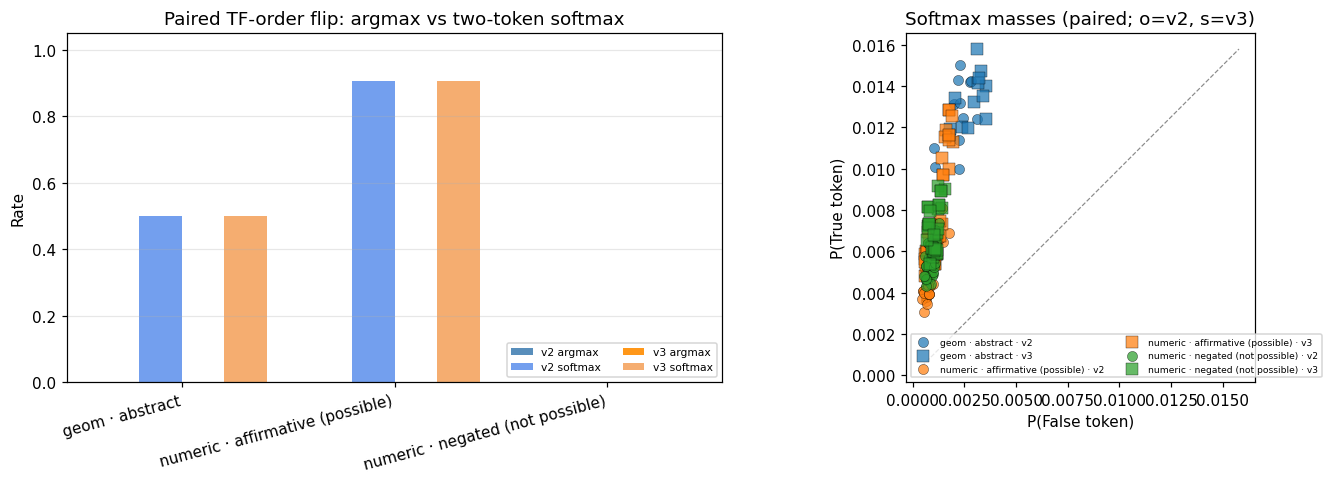

Saved /Users/Lacus/Documents/ELTE/Thesis/circuit-tracer-main/my_work/results/statistics/paired_v2_v3_first_token_breakdown.png


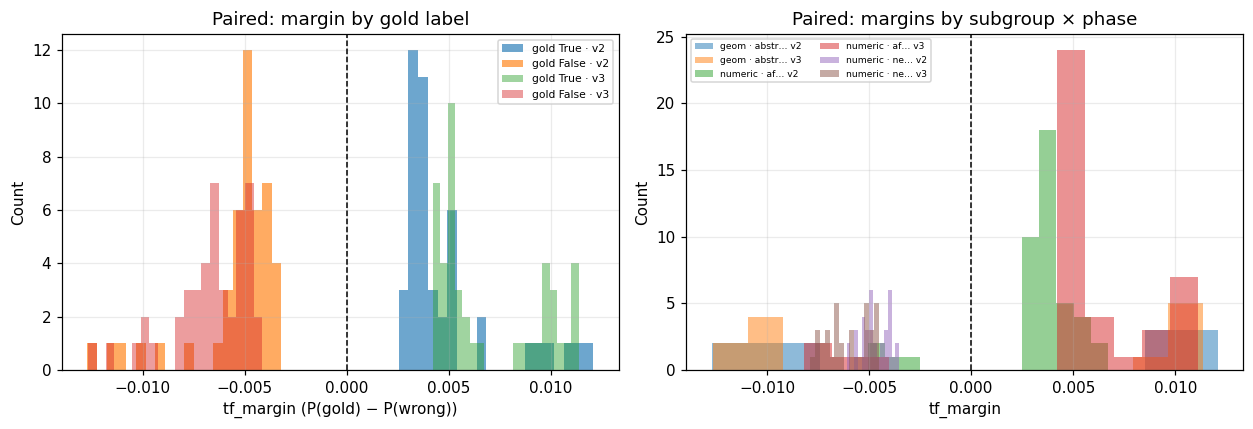

Saved /Users/Lacus/Documents/ELTE/Thesis/circuit-tracer-main/my_work/results/statistics/paired_v2_v3_first_token_margins.png


In [12]:
# ── 4b charts (paired intersection only) ───────────────────────────────────────

_groups = list(paired_long["group_label"].drop_duplicates().sort_values())
_phases = ["v2 (True or False)", "v3 (False or True)"]
_x = np.arange(len(_groups))
_w = 0.2
_offsets = [-1.5 * _w, -0.5 * _w, 0.5 * _w, 1.5 * _w]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: argmax vs softmax by group, v2 vs v3
ax0 = axes[0]
for _i, (phase, metric, color, lab) in enumerate(
    [
        ("v2 (True or False)", "argmax_acc", "steelblue", "v2 argmax"),
        ("v2 (True or False)", "softmax_truth_rate", "cornflowerblue", "v2 softmax"),
        ("v3 (False or True)", "argmax_acc", "darkorange", "v3 argmax"),
        ("v3 (False or True)", "softmax_truth_rate", "sandybrown", "v3 softmax"),
    ]
):
    _vals = []
    for g in _groups:
        row = _summary[(_summary["group_label"] == g) & (_summary["phase"] == phase)]
        _vals.append(float(row[metric].iloc[0]) if len(row) else 0.0)
    ax0.bar(_x + _offsets[_i], _vals, width=_w, label=lab, color=color, alpha=0.9)

ax0.set_xticks(_x)
ax0.set_xticklabels(_groups, rotation=15, ha="right")
ax0.set_ylim(0, 1.05)
ax0.set_ylabel("Rate")
ax0.set_title("Paired TF-order flip: argmax vs two-token softmax")
ax0.legend(fontsize=7, ncol=2, loc="lower right")
ax0.grid(axis="y", alpha=0.3)

# Right: P(False) vs P(True), colour=group, marker=phase
ax1 = axes[1]
_cmap = matplotlib.colormaps.get_cmap("tab10")
_palette = [_cmap(i % 10) for i in range(len(_groups))]
_mark = {"v2 (True or False)": "o", "v3 (False or True)": "s"}
for g, col in zip(_groups, _palette):
    for phase in _phases:
        m = (paired_long["group_label"] == g) & (paired_long["phase"] == phase)
        ax1.scatter(
            paired_long.loc[m, "prob_false"],
            paired_long.loc[m, "prob_true"],
            s=44 if phase.startswith("v2") else 52,
            alpha=0.72,
            color=col,
            marker=_mark[phase],
            edgecolors="black",
            linewidths=0.3,
            label=f"{g} · {phase.split()[0]}",
        )
mn = float(min(paired_long["prob_false"].min(), paired_long["prob_true"].min()))
mx = float(max(paired_long["prob_false"].max(), paired_long["prob_true"].max()))
ax1.plot([mn, mx], [mn, mx], "k--", lw=0.8, alpha=0.45)
ax1.set_xlabel("P(False token)")
ax1.set_ylabel("P(True token)")
ax1.set_title("Softmax masses (paired; o=v2, s=v3)")
ax1.legend(fontsize=6, ncol=2, loc="best")
ax1.set_aspect("equal", adjustable="box")

plt.tight_layout()
_out1 = MY_WORK / "results" / "statistics" / "paired_v2_v3_first_token_breakdown.png"
plt.savefig(_out1, dpi=140, bbox_inches="tight")
plt.show()
print("Saved", _out1)

# Margin histograms: gold label × phase
fig2, axs = plt.subplots(1, 2, figsize=(11.5, 4.0))
_truth = paired_long[paired_long["truth_true"]]
_false = paired_long[~paired_long["truth_true"]]
for phase, alpha in [("v2 (True or False)", 0.65), ("v3 (False or True)", 0.45)]:
    axs[0].hist(
        _truth.loc[_truth["phase"] == phase, "tf_margin"].clip(-3, 3),
        bins=20,
        alpha=alpha,
        label=f"gold True · {phase[:2]}",
    )
    axs[0].hist(
        _false.loc[_false["phase"] == phase, "tf_margin"].clip(-3, 3),
        bins=20,
        alpha=alpha,
        label=f"gold False · {phase[:2]}",
    )
axs[0].axvline(0, color="black", linestyle="--", lw=1)
axs[0].set_xlabel("tf_margin (P(gold) − P(wrong))")
axs[0].set_ylabel("Count")
axs[0].set_title("Paired: margin by gold label")
axs[0].legend(fontsize=7)
axs[0].grid(alpha=0.25)

for g in _groups:
    for phase in _phases:
        m = (paired_long["group_label"] == g) & (paired_long["phase"] == phase)
        axs[1].hist(
            paired_long.loc[m, "tf_margin"].clip(-3, 3),
            bins=14,
            alpha=0.5,
            label=f"{g[:12]}… {phase[:2]}" if len(g) > 12 else f"{g} · {phase[:2]}",
        )
axs[1].axvline(0, color="black", linestyle="--", lw=1)
axs[1].set_xlabel("tf_margin")
axs[1].set_ylabel("Count")
axs[1].set_title("Paired: margins by subgroup × phase")
axs[1].legend(fontsize=6, ncol=2)
axs[1].grid(alpha=0.25)

plt.tight_layout()
_out2 = MY_WORK / "results" / "statistics" / "paired_v2_v3_first_token_margins.png"
plt.savefig(_out2, dpi=140, bbox_inches="tight")
plt.show()
print("Saved", _out2)



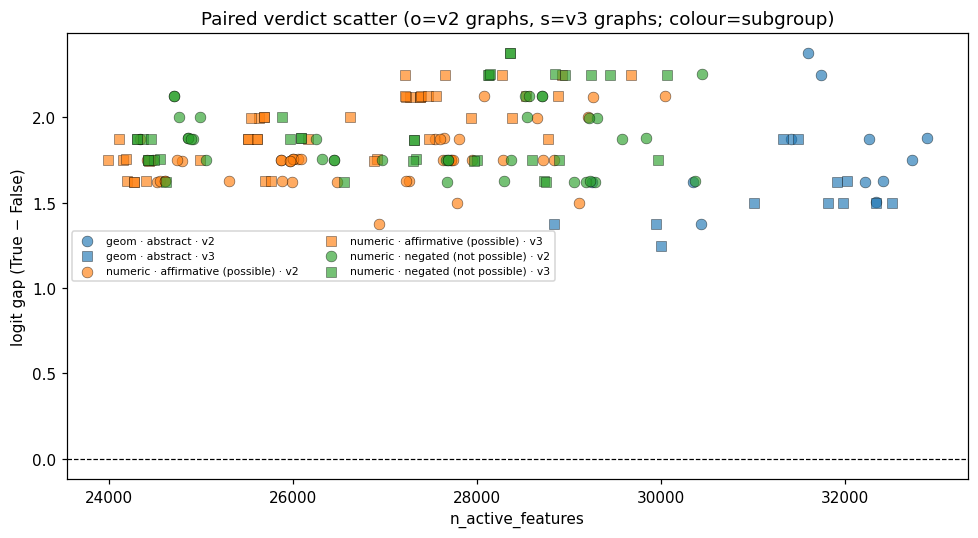

Saved /Users/Lacus/Documents/ELTE/Thesis/circuit-tracer-main/my_work/results/statistics/paired_v2_v3_verdict_scatter.png


In [13]:
# ── 4b: attribution verdict scatter on paired graphs (v2 vs v3) ─────────────

_stats_v3_all = load_statistics(STATS_V3)
stats_v3 = [s for s in _stats_v3_all if s.get("attribution_succeeded")]
_by_v2 = {s["prompt_id"]: s for s in stats}
_by_v3 = {s["prompt_id"]: s for s in stats_v3}

_scatter_rows = []
for _, r in pairs_df.iterrows():
    s2 = _by_v2.get(r["prompt_id_v2"])
    s3 = _by_v3.get(r["prompt_id_v3"])
    if not s2 or not s3:
        continue
    for phase, st in (("v2 (True or False)", s2), ("v3 (False or True)", s3)):
        if st.get("logit_gap") is None or st.get("n_active_features") is None:
            continue
        _scatter_rows.append(
            {
                "phase": phase,
                "group_label": r["group_label"],
                "truth_true": r["truth_true"],
                "n_active_features": st["n_active_features"],
                "logit_gap": st["logit_gap"],
            }
        )
paired_scatter = pd.DataFrame(_scatter_rows)

fig, ax = plt.subplots(figsize=(9, 5))
_palette = [matplotlib.colormaps.get_cmap("tab10")(i % 10) for i in range(len(_groups))]
_mark = {"v2 (True or False)": "o", "v3 (False or True)": "s"}
for g, col in zip(_groups, _palette):
    for phase in _phases:
        m = (paired_scatter["group_label"] == g) & (paired_scatter["phase"] == phase)
        if not m.any():
            continue
        ax.scatter(
            paired_scatter.loc[m, "n_active_features"],
            paired_scatter.loc[m, "logit_gap"],
            s=50,
            alpha=0.65,
            color=col,
            marker=_mark[phase],
            edgecolors="black",
            linewidths=0.35,
            label=f"{g} · {phase[:2]}",
        )
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("n_active_features")
ax.set_ylabel("logit gap (True − False)")
ax.set_title("Paired verdict scatter (o=v2 graphs, s=v3 graphs; colour=subgroup)")
ax.legend(fontsize=7, ncol=2, loc="best")
plt.tight_layout()
_out3 = MY_WORK / "results" / "statistics" / "paired_v2_v3_verdict_scatter.png"
plt.savefig(_out3, dpi=140, bbox_inches="tight")
plt.show()
print("Saved", _out3)



**takeaway**

For prompts that end with “answer with one word: True or False” (either order), the attribution fingerprint on these graphs systematically favours the True token over the False token. That looks like a format-linked bias, not a neutral read of logical truth.

It does not mean the model always generates True as the first token (§4 argmax is often wrong); it means the circuit’s True/False channel is skewed. And it does not extend to every question type in the probe — only this 90-item TF-ending intersection.

One sentence: Swapping True or False ↔ False or True doesn’t fix the bias; on logit_gap, this prompt family still always leans True, and that pattern is probably stronger than whether the gold label is True or False — but you should only claim that for these TF-style endings, not for the whole dataset.

In [14]:
# ── 4b: LOO True/False from graph stats (paired 90 only) ─────────────────────

# Feature schema aligned with §5 (aggregated layer_stats on full v2 corpus)
_paired_base_cols = [
    "n_active_features",
    "edge_density",
    "mean_top50_score",
    "top10_over_top50",
    "layer_entropy",
    "mean_error_node_weight",
    "layer_stats_mean",
    "layer_stats_std",
    "layer_stats_median",
    "layer_stats_entropy_bits",
    "topk20_score_total",
    "topk20_score_gini",
]
_prune_prefixes = ("density_at_", "n_kept_at_", "n_edges_at_", "n_nodes_total_at_", "n_edges_total_at_")
if stats_flat:
    for _k in sorted(stats_flat[0]):
        if _k.startswith(_prune_prefixes) and _k not in _paired_base_cols:
            _paired_base_cols.append(_k)

stats_v3_flat = [_flatten_nested(s) for s in stats_v3]


def _loo_block(label: str, id_col: str, stat_list, flat_list):
    """Run 5-fold CV + family LOO on paired prompts for one graph corpus."""
    pid_to_stat = {s["prompt_id"]: (sf, s) for sf, s in zip(flat_list, stat_list)}
    rows, y, groups = [], [], []
    for _, pr in pairs_df.iterrows():
        pid = pr[id_col]
        if pid not in pid_to_stat:
            continue
        sf, raw = pid_to_stat[pid]
        row = [sf.get(c) for c in _paired_base_cols]
        if any(v is None for v in row):
            continue
        try:
            rows.append(row)
            y.append(int(_binary_label_true(raw["label"])))
            groups.append(pr["family"])
        except Exception:
            continue
    if len(rows) < 12:
        print(f"{label}: too few complete rows ({len(rows)})")
        return
    X = np.array(rows)
    y = np.array(y, dtype=int)
    groups = np.array(groups)
    maj = max(y.mean(), 1 - y.mean())
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=500, C=1.0)),
    ])
    cv5 = StratifiedKFold(
        n_splits=min(5, int(y.mean() * len(y)), len(y) - 1),
        shuffle=True,
        random_state=42,
    )
    cv_scores = cross_val_score(pipe, X, y, cv=cv5, scoring="accuracy")
    loo = LeaveOneGroupOut()
    loo_scores, loo_details = [], []
    for tr, te in loo.split(X, y, groups):
        if len(np.unique(y[tr])) < 2:
            continue
        p = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=500, C=1.0)),
        ])
        p.fit(X[tr], y[tr])
        acc = p.score(X[te], y[te])
        loo_scores.append(acc)
        loo_details.append((groups[te][0], acc, len(y[te])))
    print(f"\n{label} — paired graph → True/False (n={len(rows)}, {len(_paired_base_cols)} feats)")
    print(f"  Majority baseline : {maj:.1%}")
    print(f"  5-fold CV         : {cv_scores.mean():.1%} +/- {cv_scores.std():.1%}")
    print("  Leave-one-family-out:")
    for fam, acc, nte in loo_details:
        print(f"    held-out={fam:<22}  acc={acc:.1%}  (n_test={nte})")
    if loo_scores:
        print(f"    Mean LOO          : {np.mean(loo_scores):.1%}")


_loo_block("Base v2 graphs (True or False ending)", "prompt_id_v2", stats, stats_flat)
_loo_block("Base v3 graphs (False or True ending)", "prompt_id_v3", stats_v3, stats_v3_flat)





Base v2 graphs (True or False ending) — paired graph → True/False (n=90, 47 feats)
  Majority baseline : 50.0%
  5-fold CV         : 86.7% +/- 10.3%
  Leave-one-family-out:
    held-out=geometry_claim          acc=50.0%  (n_test=12)
    held-out=numeric_validity        acc=55.1%  (n_test=78)
    Mean LOO          : 52.6%

Base v3 graphs (False or True ending) — paired graph → True/False (n=90, 47 feats)
  Majority baseline : 50.0%
  5-fold CV         : 84.4% +/- 4.2%
  Leave-one-family-out:
    held-out=geometry_claim          acc=50.0%  (n_test=12)
    held-out=numeric_validity        acc=52.6%  (n_test=78)
    Mean LOO          : 51.3%


**What this is**

On the 90 paired prompts only, a logistic model tries to predict gold True vs False from graph statistics (47 features, same schema as §5).  
You run it twice: once on v2 attribution graphs (“True or False” ending) and once on v3 graphs (“False or True” ending).  
Labels and claims are the same; only the wording order and graphs differ.

---

**Leave-one-family-out (harder test)**

Here, one whole family is missing from training (all 12 geometry or all 78 numeric).

|                  | v2  | v3  |
|------------------|-----|-----|
| Geometry held out| 50% | 50% |
| Numeric held out | 55% | 53% |
| **Mean LOO**     |52.6%|51.3%|

**Conclusion:**  
Once you hold out a whole stream, accuracy drops to roughly coin-flip (~50–55%).  
The model is not learning a rule that transfers from geometry graphs to numeric graphs (or the reverse). That matches §5’s story on the full corpus.

Flipping `True or False → False or True` barely moves LOO (52.6% vs 51.3%).  
The ending-order change does not fix cross-family generalisation.

---

**Bottom line (two sentences):**

On these 90 TF-style items, graph features still predict True/False well when both families appear in train and test (~84–87% CV), but fail as a portable truth detector across families (~51–53% LOO).  
Swapping the answer ending does not materially change either picture — the graphs carry label-linked signal in the mixed setting, not a family-agnostic notion of correctness.

## 5 — Main classifier: binary True/False from structural metrics

Supervisor-aligned evaluation:
- **Subset:** rows with `task_type == "binary"` and `family in {numeric_validity, geometry_claim}`.
- **Target:** predict True/False label (not "correct/incorrect") from structural features.
- **First code cell (§5 baseline):** `StandardScaler` + `LogisticRegression`; 5-fold CV **and** leave-one-family-out (`family`). Uses **`layer_stats_*`** + other `_flatten_nested` scalars.
- **§5b:** repeats that **same full-data CV + LOO** protocol, swapping **`layer_stats_*`** for **`layer_hist_0` … `layer_hist_{N-1}`** (per-layer active-feature counts via `feature_cols_holdout_layers`).
- **§5c:** stratified **80/20 holdout**; CV on train; same structural **`layer_hist_*`** vector (**no** stream / tail / can-cannot OHE).
- **§5d:** same holdout workflow as §5c, plus **one-hot** stream / tail / can-cannot (`possible` / `not_possible` → `can` / `cannot`; geometry rows → **`na`**).
- **Naming:** **`feature_cols_holdout_layers()`** is shared by §5b–§5d; **§5** alone keeps the **`layer_stats_*`** aggregates instead of **`layer_hist_*`**.


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, LeaveOneGroupOut

# ── Feature columns: all flattened scalars present in the data ────────────────
base_feature_cols = [
    'n_active_features', 'edge_density', 'mean_top50_score',
    'top10_over_top50', 'layer_entropy', 'mean_error_node_weight',
    'layer_stats_mean', 'layer_stats_std', 'layer_stats_median', 'layer_stats_entropy_bits',
    'topk20_score_total', 'topk20_score_gini',
]
# Add prune-curve scalars if present
_prune_prefixes = ('density_at_', 'n_kept_at_', 'n_edges_at_', 'n_nodes_total_at_', 'n_edges_total_at_')
prune_cols = sorted([k for k in (stats_flat[0] if stats_flat else {}) if k.startswith(_prune_prefixes)])
feature_cols = base_feature_cols + prune_cols

# Holdout §5c / §5d (+ §5b full-data rerun below): drop aggregate layer_stats_*; use full-graph per-layer counts layer_hist_0..
_AGG_LAYER_HOLDOUT = frozenset({
    "layer_stats_mean",
    "layer_stats_std",
    "layer_stats_median",
    "layer_stats_entropy_bits",
})


def feature_cols_holdout_layers():
    from utils.graph_statistics import N_LAYERS as _nl

    _out = []
    for _c in feature_cols:
        if _c in _AGG_LAYER_HOLDOUT:
            continue
        _out.append(_c)
        if _c == "mean_error_node_weight":
            _out.extend(f"layer_hist_{_i}" for _i in range(_nl))
    return _out


def row_values_holdout_layers(sf, raw_stat):
    """Flattened numeric row aligned with ``feature_cols_holdout_layers()``; needs ``layer_hist`` on ``raw_stat``."""
    from utils.graph_statistics import N_LAYERS as _nl

    _lh = raw_stat.get("layer_hist")
    if _lh is None:
        return None
    _lh = list(_lh)
    if len(_lh) > _nl:
        _lh = _lh[:_nl]
    _pad = _lh + [0] * (_nl - len(_lh))
    _row = []
    for _c in feature_cols_holdout_layers():
        if _c.startswith("layer_hist_"):
            _row.append(float(_pad[int(_c.rsplit("_", 1)[-1])]))
        else:
            _row.append(sf.get(_c))
    if any(_v is None for _v in _row):
        return None
    return _row

# ── Filter to binary T/F families ─────────────────────────────────────────────
TF_FAMILIES = {'numeric_validity', 'geometry_claim'}
clf_stats  = [s for s in stats if s.get('task_type', 'binary') == 'binary' and s.get('family') in TF_FAMILIES]
clf_flat   = [_flatten_nested(s) for s in clf_stats]

rows, labels, families = [], [], []
for sf, s in zip(clf_flat, clf_stats):
    row = [sf.get(c) for c in feature_cols]
    if any(v is None for v in row):
        continue
    try:
        lbl = int(_binary_label_true(s['label']))
    except Exception:
        continue
    rows.append(row)
    labels.append(lbl)
    families.append(s.get('family', '?'))

if not rows:
    print("No complete rows. Run 02 with updated graph_statistics.py first.")
    logreg_beats_majority = False
else:
    X = np.array(rows)
    y = np.array(labels, dtype=int)
    groups = np.array(families)
    majority_acc = max(y.mean(), 1 - y.mean())

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=500, C=1.0)),
    ])

    # 5-fold stratified CV
    cv5 = StratifiedKFold(n_splits=min(5, int(y.mean() * len(y)), len(y) - 1), shuffle=True, random_state=42)
    cv5_scores = cross_val_score(pipe, X, y, cv=cv5, scoring='accuracy')

    # Leave-one-family-out
    loo = LeaveOneGroupOut()
    loo_scores = []
    loo_details = []
    for train_idx, test_idx in loo.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        held_fam = groups[test_idx][0]
        # Guard: both classes must be present in train set
        if len(np.unique(y_tr)) < 2:
            loo_details.append((held_fam, None, "skipped: single class in train"))
            continue
        p = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=500, C=1.0))])
        p.fit(X_tr, y_tr)
        acc = p.score(X_te, y_te)
        loo_scores.append(acc)
        loo_details.append((held_fam, acc, f"n_test={len(y_te)}"))

    print(f"Feature matrix      : {X.shape} ({len(feature_cols)} features, {len(rows)} rows)")
    print(f"Class balance       : {y.mean():.1%} True, {1-y.mean():.1%} False")
    print(f"Majority baseline   : {majority_acc:.1%}")
    print(f"5-fold CV accuracy  : {cv5_scores.mean():.1%} +/- {cv5_scores.std():.1%}")
    print()
    print("Leave-one-family-out:")
    for fam, acc, note in loo_details:
        acc_str = f"{acc:.1%}" if acc is not None else "N/A"
        print(f"  held-out={fam:<22}  acc={acc_str}  ({note})")
    if loo_scores:
        print(f"  Mean LOO accuracy : {np.mean(loo_scores):.1%}")
    print()

    pipe.fit(X, y)
    coefs = pipe.named_steps['clf'].coef_[0]
    print("Top feature coefficients (|coef| ranked):")
    for feat, coef in sorted(zip(feature_cols, coefs), key=lambda x: -abs(x[1]))[:15]:
        print(f"  {feat:<36} {coef:>+.4f}")

    logreg_beats_majority = bool(cv5_scores.mean() > majority_acc)
    print()
    print(f"Classifier > majority baseline: {logreg_beats_majority}")
    print("(A result near 0.50 is expected and informative -- see Go/No-Go cell.)")



Feature matrix      : (270, 47) (47 features, 270 rows)
Class balance       : 50.0% True, 50.0% False
Majority baseline   : 50.0%
5-fold CV accuracy  : 79.6% +/- 4.1%

Leave-one-family-out:
  held-out=geometry_claim          acc=47.2%  (n_test=36)
  held-out=numeric_validity        acc=57.3%  (n_test=234)
  Mean LOO accuracy : 52.2%

Top feature coefficients (|coef| ranked):
  top10_over_top50                     +1.4259
  n_active_features                    -1.3763
  layer_stats_std                      +1.2131
  n_kept_at_0.50                       +1.0683
  density_at_0.70                      -1.0055
  n_edges_at_0.50                      +0.9818
  density_at_0.60                      +0.8229
  mean_top50_score                     -0.7386
  n_edges_at_0.80                      -0.5820
  n_edges_at_0.70                      -0.5293
  edge_density                         -0.4993
  layer_stats_mean                     -0.4849
  density_at_0.99                      -0.4327
  mean_erro

### 5b — Full-data classifier (**per-layer activation**), same protocol as opening §5

Re-runs **`StandardScaler` + `LogisticRegression`**, **5-fold stratified CV**, **leave-one-family-out** (`family`), and coefficient printout — the same machinery as **the first §5 code cell** — but replaces **`layer_stats_mean` … `layer_stats_entropy_bits`** with **`layer_hist_0` … `layer_hist_{N-1}`** via **`feature_cols_holdout_layers()`** / **`row_values_holdout_layers`** (full-graph counts of active attribution features **per transformer layer**).

Read off whether **dense layer-wise counts** change CV / LOO / margins versus the **four aggregate layer summaries** used in §5.


In [16]:
# ── §5b (full corpus): CV + LOO like §5, feature vector = layer_hist_* ────────

if (
    'clf_stats' not in dir()
    or 'clf_flat' not in dir()
    or not clf_stats
    or len(clf_flat) != len(clf_stats)
):
    print("Skipping §5b (layer_hist): needs clf_stats + clf_flat from §5.")
    logreg_beats_majority_layer_hist_full = False
else:
    _fch_lv = feature_cols_holdout_layers()
    rows_lv, labels_lv, families_lv = [], [], []

    for sf, s in zip(clf_flat, clf_stats):
        row = row_values_holdout_layers(sf, s)
        if row is None:
            continue
        try:
            lbl_lv = int(_binary_label_true(s["label"]))
        except Exception:
            continue
        rows_lv.append(row)
        labels_lv.append(lbl_lv)
        families_lv.append(s.get("family", "?"))

    if not rows_lv:
        print(
            "No complete rows with layer_hist for §5b. "
            "Re-run attribution + graph_statistics emitting layer_hist."
        )
        logreg_beats_majority_layer_hist_full = False
    else:
        X_lv = np.array(rows_lv)
        y_lv = np.array(labels_lv, dtype=int)
        groups_lv = np.array(families_lv)
        majority_acc_lv = max(y_lv.mean(), 1 - y_lv.mean())

        pipe_lv = Pipeline(
            [
                ("scaler", StandardScaler()),
                ("clf", LogisticRegression(max_iter=500, C=1.0)),
            ]
        )

        cv5_lv = StratifiedKFold(
            n_splits=min(5, int(y_lv.mean() * len(y_lv)), len(y_lv) - 1),
            shuffle=True,
            random_state=42,
        )
        cv5_scores_lv = cross_val_score(pipe_lv, X_lv, y_lv, cv=cv5_lv, scoring="accuracy")

        loo_lv = LeaveOneGroupOut()
        loo_scores_lv = []
        loo_details_lv = []
        for train_idx, test_idx in loo_lv.split(X_lv, y_lv, groups_lv):
            X_tr_lv, X_te_lv = X_lv[train_idx], X_lv[test_idx]
            y_tr_lv, y_te_lv = y_lv[train_idx], y_lv[test_idx]
            held_fam_lv = groups_lv[test_idx][0]
            if len(np.unique(y_tr_lv)) < 2:
                loo_details_lv.append((held_fam_lv, None, "skipped: single class in train"))
                continue
            pv = Pipeline(
                [
                    ("scaler", StandardScaler()),
                    ("clf", LogisticRegression(max_iter=500, C=1.0)),
                ]
            )
            pv.fit(X_tr_lv, y_tr_lv)
            acc_lv = pv.score(X_te_lv, y_te_lv)
            loo_scores_lv.append(acc_lv)
            loo_details_lv.append((held_fam_lv, acc_lv, f"n_test={len(y_te_lv)}"))

        print("§5b — full data, layer_hist_* in place of layer_stats_* aggregates")
        print(
            "Feature matrix      : "
            f"{X_lv.shape} ({len(_fch_lv)} features, {len(rows_lv)} rows)"
        )
        print(
            f"Class balance       : {y_lv.mean():.1%} True, {1 - y_lv.mean():.1%} False"
        )
        print(f"Majority baseline   : {majority_acc_lv:.1%}")
        print(
            f"5-fold CV accuracy  : {cv5_scores_lv.mean():.1%} +/- {cv5_scores_lv.std():.1%}"
        )
        print()
        print("Leave-one-family-out:")
        for fam_a, acc_a, note_a in loo_details_lv:
            astr = f"{acc_a:.1%}" if acc_a is not None else "N/A"
            print(f"  held-out={fam_a:<22}  acc={astr}  ({note_a})")
        if loo_scores_lv:
            print(f"  Mean LOO accuracy : {np.mean(loo_scores_lv):.1%}")
        print()

        pipe_lv.fit(X_lv, y_lv)
        coefs_lv = pipe_lv.named_steps["clf"].coef_[0]
        print(
            "Top feature coefficients (|coef| ranked), "
            "layer-activation representation:"
        )
        for feat_a, coef_a in sorted(
            zip(_fch_lv, coefs_lv), key=lambda xa: -abs(xa[1])
        )[:18]:
            print(f"  {feat_a:<36} {coef_a:>+.4f}")

        logreg_beats_majority_layer_hist_full = bool(cv5_scores_lv.mean() > majority_acc_lv)
        print()
        print(
            "Classifier > majority baseline (§5b layer_hist full data): "
            f"{logreg_beats_majority_layer_hist_full}"
        )



§5b — full data, layer_hist_* in place of layer_stats_* aggregates
Feature matrix      : (270, 69) (69 features, 270 rows)
Class balance       : 50.0% True, 50.0% False
Majority baseline   : 50.0%
5-fold CV accuracy  : 83.0% +/- 4.0%

Leave-one-family-out:
  held-out=geometry_claim          acc=50.0%  (n_test=36)
  held-out=numeric_validity        acc=61.1%  (n_test=234)
  Mean LOO accuracy : 55.6%

Top feature coefficients (|coef| ranked), layer-activation representation:
  layer_hist_20                        +1.9964
  layer_hist_18                        -1.4373
  layer_hist_14                        -1.4341
  layer_hist_12                        -1.1459
  layer_hist_22                        -1.0822
  top10_over_top50                     +1.0028
  density_at_0.70                      -0.9857
  layer_hist_24                        -0.9708
  density_at_0.60                      +0.9304
  layer_hist_4                         -0.7941
  n_kept_at_0.50                       +0.7784
  lay

### 5c — Hold-out test set (20%) + CV on the 80% train split (**structural features only**)

Same binary T/F subset, **same** stratified **`random_state=42`** 80/20 split and **`k`**-fold CV-on-train logic as §5d, but **no prompt-side columns**: model sees only the flattened graph statistics (numerics scaled; **no** stream / tail / can-cannot one-hot).

Use this as the baseline tab under the hold-out protocol **before** adding prompt-shape dummies (**§5d**).

**Feature vector** matches `feature_cols_holdout_layers()` (defined in §5): the four **`layer_stats_*`** scalars are **not** used; **`layer_hist_k`** counts active attribution features in transformer layer **`k`** (from `prompt_id`'s merged stats row).


In [17]:
from sklearn.model_selection import train_test_split

# ── §5c: stratified 80/20 holdout + CV on train — STRUCTURAL NUMERICS ONLY (no prompt OHE)

if "clf_stats" not in globals() or "feature_cols" not in globals() or not clf_stats:
    print("Skipping 5c: needs clf_stats and feature_cols from §5.")
else:
    clf_flat_b = [_flatten_nested(s) for s in clf_stats]
    _fch = feature_cols_holdout_layers()
    rows_b, y_list = [], []
    for sf, s in zip(clf_flat_b, clf_stats):
        row = row_values_holdout_layers(sf, s)
        if row is None:
            continue
        try:
            lbl = int(_binary_label_true(s["label"]))
        except Exception:
            continue
        rows_b.append(row)
        y_list.append(lbl)

    if len(rows_b) < 12:
        print(f"Skipping 5c: only {len(rows_b)} usable rows.")
    else:
        X_num = np.asarray(rows_b, dtype=float)
        y_arr = np.asarray(y_list, dtype=int)
        n_num = X_num.shape[1]

        pipe_plain = Pipeline(
            [
                ("scaler", StandardScaler()),
                ("clf", LogisticRegression(max_iter=500, C=1.0)),
            ]
        )

        X_tr, X_te, y_tr, y_te = train_test_split(
            X_num,
            y_arr,
            test_size=0.2,
            stratify=y_arr,
            random_state=42,
        )

        maj_tr = max(float(y_tr.mean()), 1.0 - float(y_tr.mean()))
        maj_te = max(float(y_te.mean()), 1.0 - float(y_te.mean()))

        k = min(5, int(y_tr.mean() * len(y_tr)), len(y_tr) - 1)
        k = max(2, k)
        cv_tr = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
        cv_tr_scores = cross_val_score(pipe_plain, X_tr, y_tr, cv=cv_tr, scoring="accuracy")

        pipe_plain.fit(X_tr, y_tr)
        test_acc = float(pipe_plain.score(X_te, y_te))

        coefs = pipe_plain.named_steps["clf"].coef_[0]
        feat_names = list(_fch)

        print("§5c — holdout + CV (structural features only; no prompt OHE)")
        print(f"Train / test rows     : {len(y_tr)} / {len(y_te)}")
        print(f"Numeric feats           : {n_num}")
        print(f"Train majority guess    : {maj_tr:.1%}")
        print(f"Train {k}-fold CV acc   : {cv_tr_scores.mean():.1%} +/- {cv_tr_scores.std():.1%}")
        print(f"Test majority guess     : {maj_te:.1%}")
        print(f"Held-out test acc       : {test_acc:.1%}")
        print()
        print("Top coefficients (|coef|) after StandardScaler on train:")
        for name, c in sorted(zip(feat_names, coefs), key=lambda t: -abs(t[1]))[:18]:
            print(f"  {str(name):<36} {c:>+.4f}")





§5c — holdout + CV (structural features only; no prompt OHE)
Train / test rows     : 216 / 54
Numeric feats           : 69
Train majority guess    : 50.0%
Train 5-fold CV acc   : 81.9% +/- 5.0%
Test majority guess     : 50.0%
Held-out test acc       : 87.0%

Top coefficients (|coef|) after StandardScaler on train:
  layer_hist_20                        +1.9443
  layer_hist_18                        -1.5697
  layer_hist_14                        -1.4860
  layer_hist_12                        -0.9275
  layer_hist_24                        -0.9229
  density_at_0.70                      -0.9056
  top10_over_top50                     +0.8540
  density_at_0.60                      +0.7483
  layer_hist_4                         -0.7386
  n_kept_at_0.50                       +0.7110
  layer_hist_15                        -0.6390
  layer_hist_9                         -0.6046
  n_edges_at_0.50                      +0.6029
  topk20_score_gini                    +0.5986
  layer_hist_2            

### 5d — Hold-out test set (20%) + CV on the 80% train split, **with prompt OHE**

Same subset and protocol as **§5c**, plus prompt metadata. We add **three** categorical fields from each stat row, then **one-hot encode** them inside the pipeline (folds never leak category vocabulary): **(1) stream** — `geom` vs `numeric` (from `family`); **(2) tail** — `answer_colon` / `the_answer_is` / `true_or_false`; **(3) can/cannot** — `possible` → `can`, `not_possible` → `cannot`, else **`na`** (geometry rows typically have no validity direction). `sklearn` concatenates the three OHE blocks.

**Procedure**

1. **Stratified 80/20 split** (`random_state=42`): test accuracy is reported **once** on the held-out 20%.
2. **5-fold stratified CV** on the **training 80% only** (same spirit as §5, but no test rows enter model selection).
3. **Pipeline:** `ColumnTransformer` → `StandardScaler` on numeric structural columns only; `OneHotEncoder(handle_unknown="ignore")` on the **three** categorical columns; then `LogisticRegression` (same settings as §5).

**Compare §5b vs §5c** to quantify how much lift comes from **prompt-shape** dummies versus **pure structure**.

Coefficient printout lists **the same `feature_cols` names** as §5b for graph metrics; OHE columns appear as **`stream_*`**, **`tail_*`**, **`can_cannot_*`** (from the fitted encoder).


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# ── §5d: stratified 80/20 holdout + 5-fold CV on train; 3 × OHE categorical block ─
#   (1) stream: geom vs numeric  (2) tail  (3) can/cannot (from claim_direction)

if "clf_stats" not in globals() or "feature_cols" not in globals() or not clf_stats:
    print("Skipping 5d: needs clf_stats and feature_cols from §5.")
else:
    def _can_cannot(cd) -> str:
        if cd is None:
            return "na"
        t = str(cd).strip().lower()
        if not t:
            return "na"
        if t in ("possible",):
            return "can"
        if t in ("not_possible", "not-possible", "impossible"):
            return "cannot"
        # unexpected but keep explicit
        return t

    clf_flat_b = [_flatten_nested(s) for s in clf_stats]
    _fch = feature_cols_holdout_layers()
    rows_b, y_list, stream_c, tail_c, cc_c = [], [], [], [], []
    for sf, s in zip(clf_flat_b, clf_stats):
        row = row_values_holdout_layers(sf, s)
        if row is None:
            continue
        try:
            lbl = int(_binary_label_true(s["label"]))
        except Exception:
            continue
        rows_b.append(row)
        y_list.append(lbl)
        fam = s.get("family") or ""
        if fam == "geometry_claim":
            stream_c.append("geom")
        elif fam == "numeric_validity":
            stream_c.append("numeric")
        else:
            stream_c.append(str(fam) or "unknown")
        tail_raw = str(s.get("tail") or "").strip()
        tail_c.append(tail_raw if tail_raw else "(missing)")
        cc_c.append(_can_cannot(s.get("claim_direction")))

    if len(rows_b) < 12:
        print(f"Skipping 5d: only {len(rows_b)} usable rows.")
    else:
        X_num = np.asarray(rows_b, dtype=float)
        y_arr = np.asarray(y_list, dtype=int)

        n_num = X_num.shape[1]
        n_cat = 3
        X_mixed = np.empty((X_num.shape[0], n_num + n_cat), dtype=object)
        X_mixed[:, :n_num] = X_num
        X_mixed[:, n_num + 0] = np.asarray(stream_c, dtype=str)
        X_mixed[:, n_num + 1] = np.asarray(tail_c, dtype=str)
        X_mixed[:, n_num + 2] = np.asarray(cc_c, dtype=str)

        cat_cols = list(range(n_num, n_num + n_cat))
        prep = ColumnTransformer(
            transformers=[
                ("num", StandardScaler(), list(range(n_num))),
                (
                    "cats",
                    OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                    cat_cols,
                ),
            ],
            verbose_feature_names_out=False,
        )
        pipe_b = Pipeline([("prep", prep), ("clf", LogisticRegression(max_iter=500, C=1.0))])

        X_tr, X_te, y_tr, y_te = train_test_split(
            X_mixed,
            y_arr,
            test_size=0.2,
            stratify=y_arr,
            random_state=42,
        )

        maj_tr = max(float(y_tr.mean()), 1.0 - float(y_tr.mean()))
        maj_te = max(float(y_te.mean()), 1.0 - float(y_te.mean()))

        k = min(5, int(y_tr.mean() * len(y_tr)), len(y_tr) - 1)
        k = max(2, k)
        cv_tr = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
        cv_tr_scores = cross_val_score(pipe_b, X_tr, y_tr, cv=cv_tr, scoring="accuracy")

        pipe_b.fit(X_tr, y_tr)
        test_acc = float(pipe_b.score(X_te, y_te))

        # Human-readable coef names: reuse §5 numeric names + sklearn OHE names on semantic labels
        _prep_fit = pipe_b.named_steps["prep"]
        _ohe = _prep_fit.named_transformers_["cats"]
        _cat_lab = ["stream", "tail", "can_cannot"]
        cat_names = list(_ohe.get_feature_names_out(_cat_lab))
        feat_out = np.asarray(list(_fch) + cat_names, dtype=object)
        coefs = pipe_b.named_steps["clf"].coef_[0]
        if len(feat_out) != len(coefs):
            raise RuntimeError(
                f"coef / name mismatch: {len(feat_out)} names vs {len(coefs)} coefs"
            )

        n_ohe = len(cat_names)
        uniq_triples = sorted({(a, b, c) for a, b, c in zip(stream_c, tail_c, cc_c)})

        print("§5d — holdout + 3 categorical columns (stream, tail, can/cannot) → OHE")
        print(f"Train / test rows     : {len(y_tr)} / {len(y_te)}")
        print(f"Numeric feats         : {n_num}")
        print(f"OHE output cols       : {n_ohe}  (stream / tail / can_cannot)")
        print(f"(stream, tail, can/cannot) levels in data ({len(uniq_triples)} triples):", uniq_triples[:14], ("..." if len(uniq_triples) > 14 else ""))
        print(f"Train majority guess : {maj_tr:.1%}")
        print(f"Train {k}-fold CV acc : {cv_tr_scores.mean():.1%} +/- {cv_tr_scores.std():.1%}")
        print(f"Test majority guess   : {maj_te:.1%}")
        print(f"Held-out test acc     : {test_acc:.1%}")
        print()
        print("Top coefficients (|coef|): structural names match §5c; categorical = stream_*, tail_*, can_cannot_*")
        for name, c in sorted(zip(feat_out, coefs), key=lambda t: -abs(t[1]))[:22]:
            print(f"  {str(name):<46} {c:>+.4f}")







§5d — holdout + 3 categorical columns (stream, tail, can/cannot) → OHE
Train / test rows     : 216 / 54
Numeric feats         : 69
OHE output cols       : 8  (stream / tail / can_cannot)
(stream, tail, can/cannot) levels in data (9 triples): [('geom', 'answer_colon', 'na'), ('geom', 'the_answer_is', 'na'), ('geom', 'true_or_false', 'na'), ('numeric', 'answer_colon', 'can'), ('numeric', 'answer_colon', 'cannot'), ('numeric', 'the_answer_is', 'can'), ('numeric', 'the_answer_is', 'cannot'), ('numeric', 'true_or_false', 'can'), ('numeric', 'true_or_false', 'cannot')] 
Train majority guess : 50.0%
Train 5-fold CV acc : 87.0% +/- 3.2%
Test majority guess   : 50.0%
Held-out test acc     : 88.9%

Top coefficients (|coef|): structural names match §5c; categorical = stream_*, tail_*, can_cannot_*
  can_cannot_cannot                              -2.5141
  can_cannot_can                                 +2.4612
  layer_hist_20                                  +1.4951
  layer_hist_11                

Section 5: Can Structure Alone Predict the Label? A Summary of Baseline Analyses

**Overview:**  
This section investigates whether the attribution graph statistics—optionally supplemented with a few prompt-related categorical features—allow a basic linear model to predict the correct T/F answer for each row in a balanced dataset. Since the dataset is balanced, random guessing yields 50% accuracy; any substantial increase over this baseline indicates that the features contain genuine predictive signal.

**5a. Mixed Setting with Numeric Structural Features:**  
 - **Inputs:** Standard numeric graph features, including four summary statistics describing attribution mass across layers.  
 - **Evaluation:** Stratified random split ensures both train and test contain geometry and numeric validity prompts.  
 - **Result:** Cross-validation achieves ~80% accuracy, meaning structure alone aligns with the label well in this setting.

**5b. Mixed Setting with Per-layer Counts:**  
 - **Inputs:** Similar setup, but replaces four summaries with per-layer non-negative counts of attribution features.  
 - **Result:** Cross-validation improves slightly to ~83%.  
 - **Interpretation:** More granular layer-wise features sharpen performance in the mixed regime.

**Leave-One-Family-Out (Prompt Stream Holdout):**  
 - **Purpose:** Test cross-family generalization—train on one prompt stream (geometry or numeric), test on the other.  
 - **Result:**  
     - Geometry-out fold: ~47%  
     - Numeric-out fold: ~57%  
     - Average: ~52%  
 - **Interpretation:** Accuracy drops to near chance; the strong result from the mixed setting does not transfer across prompt families. The model exploits correlations coexisting with the prompt type, rather than learning a universal "geometry rule."

**5c/5d. Standard Holdout with and without Categorical Metadata:**  
 - **Setup:** Revert to a single 80/20 stratified split, both sides containing both prompt streams (no cross-family test).  
 - **Results:**  
     - Structure only: ~87%  
     - With prompt stream, tail, and can/cannot OHE features: ~89%  
 - **Interpretation:** Prompt metadata modestly increases predictive power, suggesting that both how the question is posed and the underlying graph shape matter.

**Overall Conclusion:**  

Graph stats predict True vs False well above guessing when geometry and numeric rows both appear in training, so the graphs carry real signal about the labels. That signal collapses toward 50% if you withhold an entire prompt family from training, so most of what the model uses is tied to prompt stream and wording, not a clean wording-free read on “truth” alone.


## 6 — Tail diagnostic: can the fingerprint predict the prompt tail?

If structural features predict *which tail variant was used*, that confirms the fingerprint
captures format/template information (supervisor's "format detector" finding). A high accuracy
here is a meaningful positive result — it means the graph captures something real, even if it
cannot predict T/F correctness.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Use the same binary T/F family subset
tail_stats = [s for s in stats if s.get('task_type', 'binary') == 'binary' and s.get('family') in TF_FAMILIES and s.get('tail')]
tail_flat  = [_flatten_nested(s) for s in tail_stats]

tail_rows, tail_labels = [], []
for sf, s in zip(tail_flat, tail_stats):
    row = [sf.get(c) for c in feature_cols]
    if any(v is None for v in row):
        continue
    tail_rows.append(row)
    tail_labels.append(s['tail'])

if not tail_rows or len(set(tail_labels)) < 2:
    print("Not enough tail variety in the data for tail diagnostic.")
    tail_acc = None
else:
    X_t = np.array(tail_rows)
    le = LabelEncoder()
    y_t = le.fit_transform(tail_labels)

    pipe_t = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=500, C=1.0)),
    ])
    n_splits = min(5, min(np.bincount(y_t)))
    if n_splits < 2:
        print(f"Too few samples per tail class for CV (min class size = {min(np.bincount(y_t))}).")
        tail_acc = None
    else:
        cv_t = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        tail_cv_scores = cross_val_score(pipe_t, X_t, y_t, cv=cv_t, scoring='accuracy')
        tail_majority = max(np.bincount(y_t)) / len(y_t)

        print(f"Tail classes         : {le.classes_}")
        print(f"Class counts         : {np.bincount(y_t)}")
        print(f"Tail majority base   : {tail_majority:.1%}")
        print(f"CV accuracy (tail)   : {tail_cv_scores.mean():.1%} +/- {tail_cv_scores.std():.1%}")

        tail_acc = tail_cv_scores.mean()
        pipe_t.fit(X_t, y_t)
        coefs_t = pipe_t.named_steps['clf'].coef_
        print()
        print("Most discriminative features per tail class:")
        for cls_idx, cls_name in enumerate(le.classes_):
            top = sorted(zip(feature_cols, coefs_t[cls_idx]), key=lambda x: -abs(x[1]))[:5]
            top_str = ", ".join(f"{f}({c:+.2f})" for f, c in top)
            print(f"  {cls_name}: {top_str}")
        print()
        if tail_cv_scores.mean() > tail_majority:
            print("RESULT: Fingerprint does predict tail variant -- format detector confirmed.")
        else:
            print("RESULT: Fingerprint does NOT predict tail -- no strong format-detection signal.")

Tail classes         : ['answer_colon' 'the_answer_is' 'true_or_false']
Class counts         : [90 90 90]
Tail majority base   : 33.3%
CV accuracy (tail)   : 98.9% +/- 2.2%

Most discriminative features per tail class:
  answer_colon: mean_top50_score(+1.38), topk20_score_total(+1.21), layer_entropy(-0.96), layer_stats_mean(+0.85), n_edges_at_0.70(-0.52)
  the_answer_is: mean_top50_score(-1.33), topk20_score_total(-1.17), density_at_0.50(-0.94), layer_stats_mean(-0.60), mean_error_node_weight(-0.51)
  true_or_false: layer_entropy(+0.60), density_at_0.50(+0.51), n_edges_at_0.50(+0.28), layer_stats_mean(-0.25), layer_stats_entropy_bits(-0.22)

RESULT: Fingerprint does predict tail variant -- format detector confirmed.


The model is asked which prompt ending was used (answer colon vs the answer is vs true or false). There are three balanced classes (90 each), so blindly picking the modal class only gets 33%. Cross-validation reaches about 99%.

So the attribution fingerprint carries strong information about prompt format (“which template”). Different tails lean on slightly different statistic mixes (scores vs density vs entropy), which fits the idea that each wording style leaves a different trace in the graph.

**Contrast with True/False.** For the label True vs False, scores are good when both task streams are mixed in train and test (~80%+), but they fall toward chance when one whole family (geometry vs numeric) is left out of training. That pattern says: the graph tracks format and stream very reliably, but it does not give you a similarly stable, family-free read on logical truth alone.

## 7 — Per-tail facet plots: verdict scatter and key metrics

Shows whether the logit gap and key structural metrics vary by tail, enabling a visual
check of the format-detector hypothesis.

Verdict scatter: **colour** = prompt tail (**answer_colon** / **the_answer_is** / **true_or_false**); **marker** = supervised gold label (**○** True, **□** False).


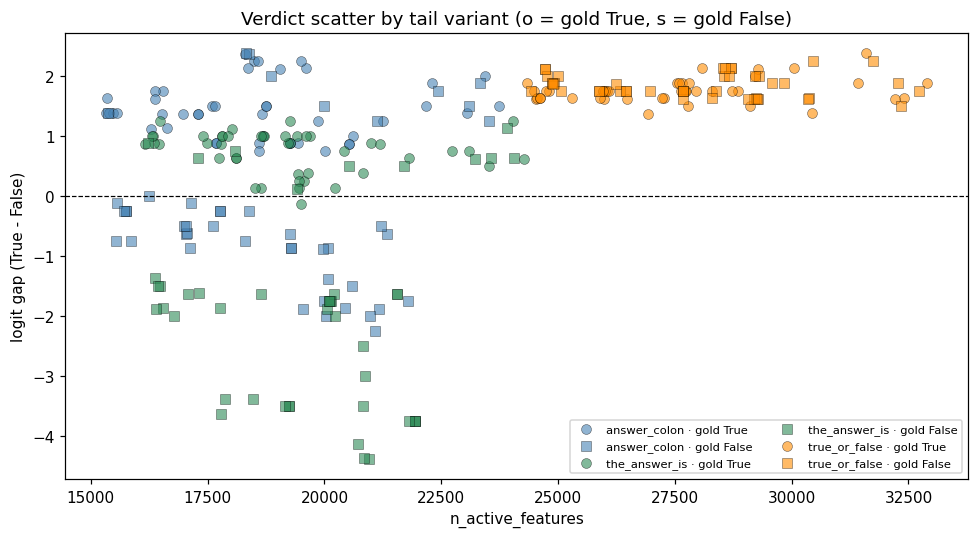

In [20]:
TAILS_ORDER = ['answer_colon', 'true_or_false', 'the_answer_is']
TAIL_COLORS = {'answer_colon': 'steelblue', 'true_or_false': 'darkorange', 'the_answer_is': 'seagreen'}

facet_stats = [s for s in binary_stats if s.get('tail')]
facet_flat  = [_flatten_nested(s) for s in facet_stats]
tails_present = sorted(set(s.get('tail') for s in facet_stats))

# ── Verdict scatter: colour = tail variant, marker shape = gold label True vs False ─
_scatter_pts = []
for sf, st in zip(facet_flat, facet_stats):
    if not st.get("tail"):
        continue
    xv = sf.get("n_active_features")
    yv = st.get("logit_gap")
    if xv is None or yv is None:
        continue
    try:
        _gold = bool(_binary_label_true(st["label"]))
    except Exception:
        continue
    _scatter_pts.append((st.get("tail"), float(xv), float(yv), _gold))

fig, ax = plt.subplots(figsize=(9, 5))
_marker_true, _marker_false = "o", "s"
_seen_leg = set()
for _tail in tails_present:
    for _want_true in (True, False):
        _xs = [_x for (_t, _x, _y, _g) in _scatter_pts if _t == _tail and _g is _want_true]
        _ys = [_y for (_t, _x, _y, _g) in _scatter_pts if _t == _tail and _g is _want_true]
        if not _xs:
            continue
        _mk = _marker_true if _want_true else _marker_false
        _lbl = f"{_tail} · gold {'True' if _want_true else 'False'}"
        ax.scatter(
            _xs,
            _ys,
            alpha=0.6,
            s=42,
            label=_lbl,
            color=TAIL_COLORS.get(_tail, "gray"),
            marker=_mk,
            edgecolors="black",
            linewidths=0.35,
        )

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel("n_active_features")
ax.set_ylabel("logit gap (True - False)")
ax.set_title("Verdict scatter by tail variant (o = gold True, s = gold False)")
hdl, lab = ax.get_legend_handles_labels()
# Keep one combined legend — at most six series (3 tails × 2 labels)
ax.legend(handles=hdl, labels=lab, fontsize=7.5, ncol=2, loc="best")
plt.tight_layout()
plt.savefig(MY_WORK / "results" / "statistics" / "base_verdict_scatter_by_tail.png", bbox_inches="tight")
plt.show()



Each dot is one prompt. Colour is how the question ends (three tail variants). Shape is the correct answer in your dataset: ○ = gold True, □ = gold False. The vertical axis is which way the circuit leans: above the dashed line = model favours answering True; below = favours False.

- **Answer-colon questions** (blue) look the most sensible: gold-True prompts mostly sit above the line, gold-False mostly below. So for this template, the leaning often lines up with the right answer—still not perfect (some overlap), but the pattern is coherent.
- **The answer is** (green) is in the same complexity band as blue, but messier. You still tend to see True cases higher and False cases lower, but False can run quite negative, so the circuit can strongly push “False” on some of these items even though the geometric picture looks similar to answer-colon on the horizontal axis.
- **True or False** questions (orange) are different in two ways. They sit at much higher “how busy the graph is” on the left–right axis. More importantly: you now see both circles and squares there, but every orange point is above the dashed line. So even when the correct answer is False (squares), the model still leans True. That is not “the task is always True”; it means this wording systematically steers the verdict toward True, including when the label is False.

Bottom line: The plot says the fingerprint tracks format very clearly. It also shows that format is not neutral: True/False wording breaks calibration (False-labelled items still look “True-leaning”), while answer-colon is the variant where True vs False in the data most matches what the logit gap is doing. So relative to predicting truth, Answer: is friendlier than explicit True/False in this visualization; the latter is dominated by a strong True bias.